# 6장 토픽 모델링의 세계관

## 1. 토픽 모델링의 기본 구도와 특징

### 1.1. 토픽 모델링이 하는 일

Part 2에 오신 것을 환영합니다. Part 2는 토픽 모델링을 다룹니다. 사실 토픽 모델링이란 말은 매우 다양한 기법을 가리키는데요, 이 강의에서는 그 중 Latent Dirichlet Allocation (LDA)과 LDA에 영향을 받은 후속 모델을 다룹니다. LDA가 중요한 까닭은, 그 기법이 나온 이후 계량적 토픽 모델링이 컴퓨터 과학이나 정보 과학의 영역을 넘어 인문사회과학은 물론 다양한 영역으로 폭넓게 영향력을 확대했다고 볼 수 있기 때문입니다. 다만 LDA라고 부르면 직관성이 떨어지고 또다른 LDA (Linear Discrimination Analysis, 선형 판별 분석)와 혼동되는 면도 있어서, 실제 하는 일을 표현하는 ‘토픽 모델링’이라는 용어를 함께 활용하고자 합니다. 즉, 이 강의에서 토픽 모델링이라 하면 그건 LDA와 그에 영향받은 후속 모델을 의미한다고 알아주십시오. 

그럼 가장 먼저, 토픽 모델링, LDA는 뭘 하는 기법인가요? 기본적으로 그것은 다수의 문서에서 역시 다수의 주제, 그러니까 토픽을 통계적으로 추정하는 기법입니다. 즉 입력이 문서 집합으로 주어지면, 출력으로 토픽들을 줍니다. 그리고 이 토픽이, 한국말로 하면 주제입니다 (이 글에서는 토픽과 주제를 같은 의미로 보고 혼용하겠습니다). 

보통 주제를 추정하는 것은 인간 고유의 능력처럼 여겨집니다. 사실 인간에게도 쉽지 않죠. 그래서 초, 중, 고등학교 시절 본문의 주제를 찾으라는 국어 시험 문제에서 많이도 틀려왔습니다. 그런데 LDA는 이걸 통계적인 절차를 거쳐 해낼 수 있도록 합니다. 


어떻게 그게 가능할까요? 그것은 데이터와 핵심 개념들을 통계 추론에 적합하도록 전환했기 때문입니다. 세 가지 전환이 특히 중요합니다. 

첫 번째로 입력인 문서를 단순한 단어의 집합 (bag of words)로 가정합니다. 토큰의 집합이라고 해도 좋지만, LDA를 비롯한 토픽 모델링 문헌들이 ‘단어’라는 용어를 활용하는 경우가 대부분이기에, 여기서도 단어라고 말하겠습니다. 문서를 단어의 집합으로 여긴다는 말은, 문서에서 활용하는 정보가 1) 출현 단어 종류 2) 각 단어의 출현 빈도로 한정한다는 의미입니다. 

두 번째로 토픽, 주제는 ‘단어의 확률 분포’로 정의합니다. 단어의 확률 분포라는 말 자체가 좀 애매한데요, 일단 단어의 확률 분포는 주어진 문서에 존재하는 모든 단어에 확률을 부여하여 묶어 놓은 것이라고 상상하면 됩니다. 예를 들어 10000개의 기사가 있는데 거기에 단어가 5000종류가 있다고 하죠. 그러면 이 5000개의 단어에 각각 확률을 부여할 수 있습니다. 즉 각 단어에 0과 1 사이의 값을 부여하고, 5000개 단어에 부여된 값을 모두 합치면 1이 되도록 하는 것입니다. [치킨 - 0.01, 피자 - 0.013, 햄버거 - 0.001, ....] 뭐 이런 식인 것이죠. 일종의 카테고리분포 (categorical distribution) 인 셈인데, 이를 '단어의 확률 분포' (probability distribution over words) 라고 부릅니다. 

토픽 모델링은 이런 단어의 확률 분포를 '토픽', 즉 '주제'라고 봅니다. 얼핏 이상한 가정이라는 생각이 들 수 있지만, 생각보다 타당한 면이 있습니다. 여러 번 말하지만 글에서 '주제'는 작성자가 전달하고자 하는 핵심 생각 혹은 사상입니다. 만약 여러 사람이 특정 주제를 표현하기 위해 여러 글을 쓰면 그 글에는 어떤 특징이 생길까요? 무엇보다 그 글들에는 독특한 '단어의 등장 패턴'이 생깁니다. 특정한 단어가 다른 단어보다 더 많이 사용되고, 나아가 자주 등장하는 단어집합이 생기지요. 예를 들어 고령화와 보험 재정이라는 주제가 존재하면, '노인'과 같은 단어가 많이 사용되고, 단순히 많이 사용될 뿐만 아니라 '보험', '부담', '재정' 같은 단어와 ‘함께 많이’ 사용되는 특징이 생긴다는 말입니다. 그런데 단어의 확률 분포는 바로 이 '주요 사용 단어 집합'에 대한 정보를 압축해서 보여주는 효과가 있습니다. 높은 확률을 부여받는 단어 집합이 그 정보를 표현하고 있지요. 이 때문에 우리는 단어의 확률 분포를 보고 주제를 추론할 수 있습니다. 토픽 모델링이 토픽/주제를 '단어의 확률 분포'로 정의하는 것이 이상한 일은 아닌거죠. 

세 번째로 개별 문서에 이런 토픽/주제가 다시 한 번 확률 분포를 이루며 존재한다고 가정합니다. 즉 문서마다 ‘토픽의 분포’ (probability distribution over topics)가 존재하는 것이죠. 예를 들어 어떤 문서에는 1번 토픽이 50%, 2번 토픽이 30%, 3번 토픽이 20% 존재한다는 보는 식이죠. 이 역시 생각보다 이상하지는 않은 가정입니다. 하나의 문서에도 여러 개의 주제가 존재할 수 있으니까요. 예를 들어 하나의 기사에 <고령화에 따른 건강 보험 재정>이라는 주제도 있고, <건강 형평성>이라는 주제도 존재할 수 있습니다. 오히려 하나의 주제만 존재하는 경우가 드물죠. 

LDA, 토픽 모델링이 하는 일은, 이 세 가지 변환에 기대어 ‘주제 탐색’이라는 작업을 통계적 작업으로 번역하는 것입니다. 핵심은 단어 집합으로 정의된 문서가 단어 확률 분포로 정의된 토픽과 문서별 토픽 분포로부터 ‘확률적으로 생성’되었다고 보고, 이 확률적 생성을 가장 잘 끌어낼 법한 토픽, 즉 단어 확률 분포와 문서별 토픽 분포를 찾아내는 것입니다. 


이는 사실 언어 자료를 대상으로 했다는 점에서 특이하게 느껴질 뿐, 통계에서 늘 하는 일에 가깝습니다. 어떤 데이터 이면의 확률 분포를 추정하는 일은 사실 우리가 중학교 때부터 확률과 통계 파트에서 문제로 풀던 일이거든요. 예를 들어 ‘동전을 100번 던졌는데 앞면이 60번이 나왔다, 동전을 던졌을 때 앞면이 나올 확률은?’ 이라는 문제를 보면, 거의 본능적으로 0.6 이렇게 푸실 겁니다. 근데 사실은 이건 [앞면 – 0.6, 뒷면 – 0.4]라는 확률 분포를 추론한 것이죠. 그리고 이런 계산 이면에는, ‘이렇게 확률 분포가 설정되어야 주어진 데이터가 확률적으로 발생할 가능성이 높다’라는 가정이 있죠. 

요컨대 LDA, 토픽 모델링은 토픽, 즉 단어 확률 분포와 문서별 토픽 분포를 두 가지 종류의 잠재 변수로 가정합니다 (엄밀히 말하면 단어별 토픽 할당 변수까지 세 종류의 잠재 변수가 있는데, 일단은 핵심 관심 사항에만 집중하겠습니다). 그 잠재 변수로부터 우리에게 주어진 데이터가 확률적으로 발생했다고 가정합니다. 그리고 그 확률적 발생을 가장 그럴 듯하게 만들 수 있는 토픽과 문서별 토픽 분포를 추론하려 합니다. 현재의 데이터, 즉 문서를 확률적으로 생성할 법한 토픽과 토픽 분포를 찾아내면, 그것이 언어 자료에 존재하는 실제 주제를 탐구하는데 유용할 것이라고 생각하는 거죠. 

확실히 감을 잡기 위해 실제 분석 결과를 한 번 보시죠. 아래는 실습을 위해 제가 가상으로 만든 기사 데이터 250개에 LDA를 적용한 것입니다. 정치, 경제, 보건, 과학기술, 스포츠라는 다섯 개의 주제를 가정한 가상 기사 데이터를 만들었는데, 거기에 Gensim이라는 라이브러리를 통해 LDA를 적용하였습니다. 주제가 몇 개나 있는지 알지 못한다고 가정하고, 주제를 네 개로 설정해서 결과를 산출해보았습니다.

<div style="text-align:center;">
    <img src="_static/figures/6장 LDA 예시 1.jpg" width="600">
</div>


우선 네 개의 토픽을 막대 그래프로 시각화한 것입니다. 토픽은 단어의 확률 분포인데, 여기서 가장 높은 확률을 할당 받은 10개의 단어만 확률과 함께 시각화한 것입니다. 이를 보고 각 토픽에서 중요 대상이 뭔지, 어떤 중요 단어 집합이 포착되는지 알 수 있습니다. 이걸 보고 토픽에서 주제를 해석해 낼 수 있습니다. 예를 들어 3번 토픽은 백신, 보건, 의사 같은 단어가 등장하는 것을 보니, '보건의료'라는 주제라고 짐작할 수 있습니다.  

말씀드렸듯이 각 문서마다 이 네 개의 토픽이 비중을 달리하면서 존재합니다. 즉 문서 마다 토픽 확률 분포가 있는 거죠. 100번째 문서, 200번째 문서가 네 개의 토픽을 어느 정도 비중으로 포함하고 있는지도 이어서 시각화 해보았습니다. 

<div style="text-align:center;">
    <img src="_static/figures/6장 LDA 예시 2.jpg" width="600">
</div>

문서마다 토픽 비중의 분포가 제각각이네요. 이는 목적에 따라 중요한 정보로 활용할 수 있습니다. 그리고 제법 잘 추정한거 같습니다. 실제 100번째 문서와 200번째 문서는 아래와 같거든요. 

- 100번째 문서: 예방과 의사 관련 논의가 이어지고 있다. 증상 중심으로 의료 변화가 나타나고 있다.
- 200번째 문서: 우승를 둘러싼 관심이 커지고 있다. 현장에서는 득점와 대표팀 문제를 함께 살펴보고 있다. 특히 대회 흐름이 중요한 변수로 거론된다.

### 1.2.	주제 탐구에서 토픽 모델링이 주는 실질적 장점

이제 토픽 모델링, LDA가 대략 어떤 출력을 주는지 파악하셨을 듯합니다. 자 그럼 잠시 숨을 돌리고 생각해봅시다. 이런 방식으로 출력을 얻으면 주제 연구에 어떤 장점이 있을까요? 

사실 문서들로부터 탐색적으로 주제를 연구하는 방법이 토픽 모델링만 있는건 아닙니다. 계량적인 방법들로 한정해도 그렇습니다. 당장 우리도 앞에서 커뮤니티 탐지 알고리즘을 활용해서 해봤었죠. 4장의 내용이 그거였습니다. 

그런데 커뮤니티 탐지는 사실 주제 탐구를 위해서 만들어진 기법이 아닙니다. 말 그대로 네트워크에서 커뮤니티 구조 탐지하려고 고안된 것이죠. 다만 우리가 주제나 프레임이 두드러진다면 토큰 혹은 단어 네트워크에서 커뮤니티 구조를 남길 것이라는 가정 하에 그렇게 활용한 것뿐입니다. 즉 커뮤니티 구조를 주제 탐색의 단서로 삼은 것이지요. 그래서 사실 네트워크 커뮤니티 결과는 주제 탐색이라는 목표를 고려하면 몇 가지 불편한 점이 있습니다. 불편함의 핵심은 이런 것들입니다. 

첫째, 결과가 표준화되어 있지 않습니다. 토큰 네트워크에서 커뮤니티는 본질적으로 노드 집합입니다. 그리고 커뮤니티마다 그것을 구성하는 노드 숫자, 그러니까 이 경우에는 단어의 숫자가 다릅니다. 어떤 커뮤니티는 단어 20개로 구성되어 있고, 다른 커뮤니티는 단어 50개로 구성되어 있는 식이죠. 그래서 커뮤니티 마다 주제를 추적하는데 활용할 수 있는 정보량에 차이가 있습니다. 주제들을 일관된 기준으로 비교하거나 해석하려고 하면 이런 면이 어려움을 가져올 수 있습니다. 

둘째, 전체 코퍼스가 아니라 문서와 같은 하위 단위에서 주제가 가질 수 있는 여러 현상, 예를 들어 문서 내 비중이나 출현 강도 등을 분석하기가 애매합니다. 꼭 하자면 할 수는 있는데, 연구자의 판단이 꽤 많이 내려져야 합니다. 예를 들어서 커뮤니티 결과를 벡터로 전환하고, 그것과 문서의 유사도 (cosine similarity 등을 활용하는 거죠)를 측정하고, 그걸 표준화하는 형식으로 진행하는 경우가 있습니다. 앞에서 예로 든 논문이 바로 그런 방식으로 진행하죠. 하지만 이 과정에서 꽤 많은 연구자의 자체적 판단과 추가적 분석이 필요합니다. 즉 복잡하다는 말입니다. 

셋째, 무엇보다 커뮤니티는 주제가 아닙니다. 주제가 남긴 구조상의 흔적입니다. 그 흔적을 보고 우리가 주제를 추적, 탐색하는 것이지요. 

반면 우리가 앞에서 간단히 살펴본 토픽 모델링, LDA는 확실히 위와 같은 지점에서 편리함을 가져다줍니다. 

첫째, 토픽, 주제가 확률 분포라는 표준화된 형식을 가집니다. 모든 토픽은 단어 확률 분포입니다. 이렇게 되니, 분석자 입장에서 해석과 소통이 편합니다. 계량적 분석에 관심을 가진 우리는 이미 확률 분포라는 것에 익숙합니다. 일단 이해가 편하죠. 누군가에게 설명할 때에도 어렵지 않습니다. 예를 들어 이 주제에서 이 단어가 높은 확률을 가지기에 중요 대상이라고 말하는 것은 누구에게도 그리 어색하게 다가가지 않습니다. 토픽 간 비교 분석도 더 쉽습니다. 토픽의 기본 형태는 확률 분포지만, 그것에 기반한 여러 파생 지표도 손쉽게 만들 수 있지요. 

둘째, 문서 마다 토픽 분포를 주는 것도 장점입니다. 코퍼스 단위에서 주제를 탐색할 뿐 아니라, 주제마다의 존재 강도 혹은 차지하는 비중을 볼 수 있는 셈이니까요. 그 경우 문서의 부대 정보 (예를 들어 생성 시점) 과 결합할 경우, 다양한 응용이 가능해집니다. 예를 들어 시간에 따라 특정 토픽, 주제의 비중이 전체 코퍼스에서 어떻게 달라지는지 분석하는 것도 가능하겠지요. 

셋째, 주제를 직접 계량적으로 정의하고, 잠재 구조의 위치에 놓습니다. 즉 주제, 토픽이란 단어의 확률 분포라고 정의해버리고, 이 토픽들과 문서별 토픽 분포로부터 문서가 생성된다고 가정합니다. 이렇게 함으로써 토픽, 즉 주제를 직접적인 출력으로 줍니다. 

물론 잊지 말아야 할 것이 있습니다. 그럼에도 불구하고 토픽 모델링의 ‘토픽’이 우리가 개념적으로 말하는 주제 혹은 토픽과 다르다는 점입니다. 단어 확률 분포가 토픽이라는 정의는 토픽 모델링의 세계관에서만 통용될 뿐입니다. 실제 우리가 관심을 가진 토픽 혹은 주제는 그것과는 분명 다르지요. 구체적인 이야기는 물론 개념들 사이의 복잡한 관계에 대한 지식을 포함합니다. 그 서사와 관계는, 단어들에 확률이라는 가중치를 붙여서 모아놓은 수학적 구성물로는 다 표현하기 힘듭니다. 즉 엄밀히 보자면 단어의 확률 분포 역시 우리가 탐구하는 주제 자체는 아닙니다. 

하지만 저는 그렇다고 해서 토픽 모델링의 토픽 역시 단서에 불과하며 다른 접근에 비해 나은게 없다고 말할 수는 없다고 생각합니다. 토픽 모델링의 토픽은 일종의 ‘불완전한 조작적 정의’입니다. 어쨌든 문서 집합의 생성을 좌우하는 잠재 구조로서의 주제를 직접적인 분석 목표로 삼고 있지만, 그것을 계량적으로 다루기 위해 조작적으로 정의해야 했고, 그 결과가 개념적 정의를 다 담지 못하고 있는 것이죠. 이것이, 아예 다른 개념을 겨냥했는데 주제 탐구의 단서로 활용하는 것과 (마치 네트워크에서 커뮤니티 구조처럼) 동일하다고 볼 수 없습니다. 목표를 주제 탐구로 한정하다면, 분석자에게 다양한 추가적인 정보를 제공하는 결과입니다. 

예를 들어 토픽 모델링의 토픽은 주제로부터 문서가 발생하는 과정을 나름대로 근사 (approximate) 합니다. 확률적 발생이 주제를 염두에 둔 인간이 글을 쓰거나 말하는 과정과 동일하지는 않지만, 적어도 그걸 나름의 방식으로 재현하죠. 토큰 네트워크의 커뮤니티는 아예 이런 것이 불가능합니다. 그리고 불완전한 근사는 여러 활용 가능성이 있죠. 

개념적 수준의 친연성 또한 연구에 유용한 면입니다. 개념적 정의에서 주제는 문서 이면의 잠재 구조 같은 위상을 가집니다. 프레임, 담론 모두 마찬가지죠. 이것들은 단순히 문서에서 명백히 관찰할 수 있는 패턴을 요약한 것과는 다릅니다. 그런데 토픽 모델링의 토픽 역시 잠재 변수입니다. 즉 토픽은 우리가 관심을 가진 이론적 개념 (주제, 프레임, 담론) 과 개념적 수준의 친연성을 가진다고 볼 수 있습니다. 만약 우리가 이런 이론적 개념의 잠재 구조적 면과 발생에 대해 가지는 기여를 강조하고 싶다면, 이런 개념적 친연성은 분명 설명과 해석에 도움이 됩니다. 

### 1.3. 토픽 모델링이 포기하는 것

물론 토픽 모델링, LDA가 이런 장점을 얻는 대신 희생하는 것이 분명 있습니다. 가장 두드러진 희생은 토큰 혹은 단어 간의 다양한 관계 정보와 언어 자료에 존재하는 다채로운 구조 정보를 잃어버리는 점입니다. 앞서 말했듯이 토픽 모델링은 문서를 단어의 집합, 즉 bag of words로 가정합니다. 사실 이런 단순화를 거쳐야만, 단어 확률 분포와 문서별 토픽 분포로부터 문서가 발생한다는 가정을 세울 수 있습니다. 그렇기에 다양한 관계 정보, 예를 들어 단어 혹은 토큰의 문장 동시 출현, 단락 동시 출현, 근접 출현 등이 모두 고려되지 않습니다. 구조 정보도 마찬가지입니다. 언어 자료에는 문장, 단락, 순서 등 다양한 구조적 정보가 있는데, 토픽 모델링에서는 적극적으로 활용되지 않습니다.

요컨대 **토픽 모델링은 모든 모델이 그렇듯이 선택을 하고 있습니다.** 모델은 근본적으로 현상의 단순화입니다. 그리고 단순화는 실제 현상에서 무언가를 부각하기 위해 무언가를 희생하는 과정을 동반하죠. 토픽 모델링은 대량 언어 자료에서 주제를 탐구하기 위해 주제, 토픽이라는 잠재 변수를 명시적으로 단어 확률 분포로 정의하고, 그로부터 자료의 발생의 과정 역시 명시적으로 정의합니다. 그런 다음 토픽과 토픽 분포를 통계적으로 추론합니다. 이 덕분에 우리는 주제라는 개념과 상대적으로 가까운 위상의 수학적 구조물을 확률 분포라는 정형화된 형식으로 얻어낼 수 있습니다. 대신 문서에 존재하는 다양한 구조 정보와 단어 사이의 다양한 관계 정보를 고려하지 않게 되는 것이죠. 

여담이지만 네트워크 과학을 활용한 분석에서는 문서에 존재하는 다양한 구조 정보와 단어 사이의 다양한 관계 정보를 분석자가 선택하여 반영할 수 있습니다. 링크의 정의를 다채롭게 하면 관계 정보와 구조 정보를 다양하게 반영할 수 있기 때문입니다. 그런 면에서 토픽 모델링과 네트워크 과학에 기댄 분석은 상호 보완적 관계가 될 수 있습니다. 

즉 토픽 모델링은 만능도 아니고 주제 탐구에서 가장 우월한 모델이라고도 하기 어렵습니다. 하지만 이 모델의 장점이 필요한 순간에는 유용하다고는 할 수 있습니다. 그 상황은 다음과 같습니다. 
- 대량 자료에서 자동으로 주제를 포착하여 그것을 설명하고 소통해야 할 때: 확률 분포라는 형식에 기대어 설명이 용이합니다. 
- 문서 수준의 토픽 비중 분포를 보고 비교 분석해야 할 때: 앞서 말했듯 문서에 존재하는 부속 정보 (문서 생성 시점 등) 까지 고려하면, 토픽의 비중과 다른 변수 사이의 상관관계까지 분석을 확대할 수 있습니다. (참고로 이걸 염두에 두고 또 모델 차원에서 구현하는 기법들도 존재합니다. Structural topic model이 대표적이죠.)

다만 이런 장점은 여러 정보를 의도적으로 무시한 결과 얻어진 것이라는 점을 분석자가 항상 염두에 둬야 합니다. 

## 2. 토픽 모델링과 여러 연구들

Part 2에서는 이런 토픽 모델링이 어떻게 두 가지 확률 분포를 추론하는지 구체적인 절차와 방법에 대해 설명할 것입니다. 사실 입력과 출력 형태만 알면 실행 자체는 문제가 아닙니다. 토픽 모델링을 구현한 라이브러리는 많고, 매뉴얼도 잘 되어 있습니다. 파이썬에서는 Gensim, R에서는 topicmodels 같은 라이브러리가 대표적이죠. 

다만 여기서 멈추면 연구자가 마주할 법한 여러 질문에 대답하기는 어렵습니다. 어떤 방식으로 출력, 즉 단어 확률 분포를 도출하였는지, 그건 얼마나 믿을 만한지, 이런 방법이 가지는 단점은 무엇인지, 이러 저러한 특징을 가진 데이터 셋에 적용해도 되는지, 결과 해석에서 주의해야 할 사항은 무엇인지, 이런 질문들 말이죠. 그래서 이 강의에서는, LDA를 기준으로 출력이 만들어지는 전반적인 과정을 자세히 살펴보고, 그것을 이해하는데 필요한 수학적 도구들을 가능한 빠짐없이 설명하려고 할 것입니다. 그래야 독자 분들이 토픽 모델링의 전반적 수학적 원리를 이해하고, 이 방법을 신비화하지 않은 상태에서 이 모델의 장점을 최대한 이용하실 수 있기 때문입니다. 

하지만 본격적으로 그 설명을 하기 전에, 이 방법으로 실제 어떤 연구를 할 수 있는지 좀 더 사례를 보여드리고 시작하려 합니다. 왜냐하면 일단 그 설명이 시작되면, 매우 긴 시간 동안 베이지안 추론과 사후 분포 근사 방법에 대해 배우게 될 것입니다. 아마도 [마음의 구조와 자연어 처리] 강의 전체에서 가장 이론적으로 서술될 파트가 아닐까 싶습니다. 바로 이걸 다룰 수도 있습니다만, 그렇게 되면 만약 제가 독자라면 '내가 이걸 왜 보고 있지, 애초에 토픽모델링은 뭘 하는 방법이지' 하는 생각이 들 듯하여^^, 서론이 길어지는 감이 있습니다만, 실제 토픽 모델링을 활용하여 무엇을 연구할 수 있는지 사례를 말씀드리고자 합니다. 

저는 토픽 모델링을 주제를 탐색적으로 발견하는 것 이외에도, '담론' 연구나 '프레임' 연구에도 쓸 수 있다고 생각하고, 실제로 그렇게 써왔습니다. 그리고 이런 연구들이 큰 차원에서 <마음의 구조 연구>에 해당한다고 생각합니다. 담론에 대한 연구는 주로 거시적이고 장기간 지속되는 수준에서 우리의 무의식적 전제가 어떻게 바뀌어 왔는지 연구한 사례가 많았습니다. 예를 들어 푸코가 '임상의학담론'의 특이성을 설명한 것이 대표적이지요. 프레임은 그보다는 좀 더 짧은 시간대에서 작동하는 개념이라 볼 수 있지만, 프레임 연구 역시 어떤 다면적 실체에 대한 언어적 표현이 무엇을 강조하냐에 따라 사람들의 반응이 어떻게 바뀌는지에 대한 실증적 연구를 많이 쌓아왔습니다. 예를 들어 어떤 보건 정책에 대해 재정 부담을 강조하는 기사가 많을 때와 수혜 내용을 강조하는 기사가 많을 때의 여론의 차이 등을 바라보는 식이지요.

보통 이런 담론이나 프레임의 연구는 인간이 문헌 자료를 면밀히 분석하는 방식으로 진행하는 경우가 많았습니다. 그런데 인간의 독해력에 기댄 연구는, 인간의 종합적 해석 능력을 활용할 수 있다는 장점이 있지만, 자료의 양을 늘리기가 힘듭니다. 인간이 읽을 수 있는 자료의 양에는 한계가 존재하니까요. 그런데 토픽 모델링은 인간의 해석 노력을 완전히 없애지는 못하지만 그 노력을 대폭 감소시키는 효과를 가집니다. 왜냐하면 토픽 모델링은 대량 자료를 입력으로 받아도 꽤 빠른 시간 안에 '단어의 확률 분포'로 정의된 다수의 주제를 출력으로 주고, 그 '단어의 확률 분포'가 담론이나 프레임을 파악하는데 꽤 유용한 정보를 제공하기 때문입니다. 즉, 담론이나 프레임 연구, 좀 더 넓게 봐서 마음의 구조 연구에 토픽 모델링을 도구로 활용될 수 있다는 말입니다. 

어째서 토픽이 담론이나 프레임에 대한 유용한 정보를 제공할까요? 이를 위해 목표로 삼은 개념이 무엇인지 알아야 합니다. 우선 담론을 예시로 설명해보겠습니다. 담론이란 무엇인가요? 매우 단순화해서 말하면, 담론은 '누가 말할 수 있는가?', '무엇에 대해 말해야 하는가?', '어떻게 말해야 하는가?' 등을 규정하는 언어 이면의 규칙입니다. 예를 들어 임상의학담론의 영향력이 절대적이면, 그 영향력이 발휘되는 시공간에는 질병에 대해 말할 수 있는 자의 자격과, 질병에서 중요한 대상과, 그것에 대해 말하는 방식에 대한 규칙이 강하게 작동합니다. 질병에 대해 말할 수 있는 자는 의료전문직으로 한정되고, 질병에 대해 이야기할 때는 해부학적 병소가 중심 대상이 되며, 그것을 논의하는 과학적 방식이 정의되는 식입니다. 자격이 없는 자가 엉뚱한 대상에 대해 정해지지 않은 방식으로 말하면, 예를 들어 저 같은 사회학 연구자가 질병에서 장기 지속하는 문화적 배경에 대해 에세이 같은 글을 써서 발표하면, 그리 중요치 않은 말로, 좀 심하면 소음으로 취급될 지도 모르지요. 물론 지금 그렇다는 말은 아닙니다. 임상의학담론 이외에도 경쟁 담론들이 꽤 많고, 많아지고 있으니까요. 특히 환자 경험과 관련된 영역은 주류적인 담론으로 자리잡고 있는 듯합니다.

이런 것이 담론이라고 할 때, 특정한 담론이 강하게 존재하면, 언어 자료에 어떤 흔적이 남을까요? 만약 정말 그런 언어 이면의 규칙이 있다면, 자료에는 '자격 있는 자'를 가리키는 단어가 많이 등장할 것입니다. 예를 들어 '의사'나 '과학자'가 그런 단어겠지요. 더불어 '중요 대상'도 등장하겠지요. '세포'나 '조직' 등이 그런 것일 공산이 클 것입니다. 그리고 이들을 언급하는 방식에서 주로 사용되는 단어도 많이 등장할 것입니다. '현미경', '바이오마커', '실험', '데이터' 등의 단어들이 소위 과학적 탐구 방식을 강조하는 과정에서 많이 쓰이겠지요. 그러면 자연히 이들이 토픽 모델링의 결과인 단어 확률 분포에서 고확률 단어군을 형성할 것입니다. 만약 정말 그런 규칙이 두드러지게 존재한다면 말이죠. 

즉 담론이 있으면, 주목해야 할 대상들이 정해지고, 그것에 대한 특별한 스타일의 이야기가, 말할 수 있는 자의 관점에서 만들어집니다. 이처럼 관점과 대상이 뚜렷한 이야기 각각이 주제로 표현될 공산이 큽니다. 그리고 토픽은 이런 주요 대상들을 둘러싼 주제를 포착하고 확률 분포로 표현하겠지요. 그러면 분석자는 토픽으로 포착된 주제를 보면서 이들을 종합하여 역으로 담론을 추적하는 일이 가능할 것입니다. 즉 토픽으로 표현된 여러 주제를 보고, 거꾸로 '누가 말할 수 있는가?', '무엇에 대해 말해야 하는가?', '어떻게 말해야 하는가?'에 대한 규칙을 추적할 수 있다는 말입니다.

담론만이 아닙니다. 프레임을 탐구하는 작업에도 활용할 수 있을 것입니다. 프레임이란, 복잡한 다면적 실체에서 특정 면을 '선택'(selection) 하여 '부각'(salience) 하는 언어 구조입니다. 주유소의 동일한 가격 정책을 두고, '현금으로 사면 10% 싸다'고 특정한 면을 강조할 수 있고, '카드로 사면 10% 비싸다'고 강조할 수도 있는 것처럼 말이지요. 만약 이런 프레임이 있고 두드러진다면, 당연히 선택되는 대상들과 대상들의 연결 구조가 존재할 것입니다. 해당 프레임을 반영한 구체적인 스토리가 존재할 것이고, 그것들이 특정한 주제로 표현되겠지요. 담론에서 그랬던 것처럼 토픽으로 표현된 주제들을 보고 연구자가 프레임을 추론하는 것이 가능할 것입니다. 

즉 토픽으로 표현된 주제들은 우리가 관심을 가진 여러 개념에 대한 정보가 됩니다. 연구자/분석자는 자신이 관심을 둔 개념을 탐구하는데 이들을 활용할 수 있을 것입니다. 그 활용방식은 관심을 둔 개념에 따라 다르겠지요. 예를 들어 담론에 대해 연구할 때에는 '누가 말할 수 있는가?' 즉 진리 생산의 자격에 큰 관심을 두곤 하는데, 그 관점에서 토픽들을 활용하는 것은 일반적인 프레임을 찾을 때 활용하는 방식과는 다를 것입니다. 

좀 더 구체적인 예를 들어 볼까요? 저는 과거에 '울분'을 기사에 포함한 기사를 모두 모아서 STM이라는 기법으로 토픽들을 추정한 적이 있습니다. STM은 나중에 설명하겠지만, LDA의 세계관을 이어받은 기법 중 하나입니다. 제가 추출한 여러 토픽 27번째 토픽은 아래와 같은 단어들에게 높은 확률을 부여했습니다 (Highest Prob). 그리고 해당 토픽이 높은 비중을 갖는 기사들의 제목은 아래와 같았습니다.

-----------------------------------------------------------
**Topic 27 Top Words**
- Highest Prob: 광주, 민주화, 운동, 박정희, 역사, 정권, 전두환, 김대중, 대통령, 사건, 민주, 고문, 학생, 유신, 사람

**Topic 27이 높은 비중 차지한 기사 제목들**
- 5.18 광주항쟁 25주년 / '5.18묘지' 눈물의 역사
- 학우여 기억하는가, 등사기로 밀던 유인물을
- 28년 만에 돌아온 가방 /학우여 기억하는가, 등사기로 밀던 유인물을
- <어제의 오늘> 1980년 광주민주화운동 발발
-----------------------------------------------------------


저는 이 결과를 보고 주제를 추론할 수 있었습니다. 그리고 이 토픽에 이름을 붙였습니다. <5.18 광주민주화 항쟁 및 민주화 항쟁에서 비롯한 울분>이 제가 붙인 이름이었습니다. 여담이지만, 토픽 모델링 결과인 토픽에 분석자가 나름대로 이름을 붙이는 경우가 꽤 많습니다. 그래야 소통이 더 편하니까요. 저는 이렇게 이름을 붙인 토픽의 비중 데이터도 함께 얻을 수 있었습니다. 각 기사의 생성 시점과 연동하여 시간에 따른 비중 변동까지 추론할 수 있었지요. 이 분석을 할 때 그렇게 하지는 못했습니다만, 추가적으로 발언권을 가질 수 있는 위치와 주요 대상에 대한 면밀한 분석이 뒤따랐다면 담론에까지 논의를 확장할 수 있었을 지도 모릅니다. 

토픽 모델링이 기본적으로 가지는 '복수 토픽'에 대한 가정은 이런 다양한 연구 과정을 정교하게 만드는데 큰 도움이 됩니다. 프레임이든, 담론이든, 주제든, 인간사에 딱 하나만 존재하는 경우가 오히려 드뭅니다. 오히려 여러 담론, 주제, 프레임이 경쟁하는 경우가 일반적이지요. 그런데 인간이 직접 문헌을 보고 그렇게 경쟁하는 언어 구조 모두를 잡아내는 것은 생각보다 쉽지 않습니다. 매우 작은 비중을 갖고 있는 소수적인 구조의 경우 신경을 매우 곤두세워야 포착할 수 있을 것입니다. 제대로 포착하지 못하고 누락하는게 오히려 자연스럽겠죠. 그런데 토픽 모델링은 여러 토픽의 존재 가정을 가지고, 이들의 비중 역시 공평하지 않다는 가정을 가지기에 소규모로 존재하는 경쟁적 언어 구조도 잡아낼 가능성을 가집니다. 이런 특징은 경쟁하는 담론이나 프레임 구조를 읽어내는데 효과적일 수 있습니다. 

요컨대 토픽 모델링이 주는 토픽은 기본적으로 주제에 대한 정보를 줍니다. 우리가 생각하는 주제 자체는 아닐지 모르겠지만, 그에 대한 정보를 제공하죠. 게다가 이 토픽을 코퍼스에서 여러 개 추출해주고, 문서별로 토픽의 비중까지 추정해줍니다. 이런 정보들을 종합하면, 연구자가 관심을 둔 다양한 개념의 연구에 활용할 수 있습니다. 담론이나 프레임이 대표적입니다. 나아가 문화 연구나 여론 연구로 확장하지 못할 이유가 없죠. 그들 모두, 인간이 만들어낸 언어 자료에 특정한 흔적을 남기고, 토픽이 그 흔적을 추적하는데 활용 가능하기 때문입니다. 물론 목표 개념에 따라 활용 방식은 다르겠지만요. 

이런 방식의 활용은 특히 인간이 직접 자료를 모두 읽기가 어려운 상황에서 유용합니다. 예를 들어 어떤 연구자가 연구 주제상 원칙적으로 살펴보고 싶은 신문기사가 5만건이라면, 이를 다 읽는 것은 불가능할 것입니다. 여러 명이서 팀을 구성해도 힘들 것입니다. 그런데 거기서 추출된 100개의 토픽을 검토하는 건 충분히 가능하죠. **100개의 토픽이 주제는 물론 담론이나 프레임 자체라고 할 수는 없지만**, 그 100개의 토픽이 제공하는 정보를 종합하여 활용하면, 충분히 그것들을 연구하는 것이 가능합니다. 

토픽 모델링이 컴퓨터 과학의 영역을 넘어 여러 영역에서 주목 받았던 것은 아마도 이런 풍부한 활용 가능성 때문일 것입니다. 앞서 말했듯, 단어 확률 분포라는 정규화된 형태로 여러 주제에 대한 단서를 제공하는 것은, 연구자에게 익숙한 언어로 정리된 정보를 제공한 의미가 있었거든요. 독자 여러분의 연구에도 분명 도움이 될 것이라 생각합니다. 

자 그러면 이제 본격적으로, 토픽 모델링이 토픽을 어떻게 추정하는지 구체적으로 알아봅시다. 지금까지 한 모든 이야기는 LDA를 비롯한 여러 기법이 토픽을 '잘' 추정한다는 전제 위에서 이루어졌습니다. 대체 어떻게 이렇게 '잘' 추정하는지 알아봅시다. 

## 3. 토픽을 추정하는 다양한 전략과 베이지안 통계

토픽 모델링 기법들이 가진 유용성의 대전제는, 일단 데이터에서 토픽 (단어의 확률 분포) 과 문서별 토픽 분포를 잘, 훌륭하게 얻어낼 수 있다는 것입니다. 그리고 잘 얻어냈다 혹은 훌륭하게 얻어냈다는 판단의 기준은, 앞서 말했듯 문서 데이터가 어떤 확률적 절차를 통해 생성되었다고 가정할 때 우리가 가정한 토픽과 토픽 분포가 주어진 데이터를 만들어 낼 법하냐에 있습니다. 즉 이렇게 토픽과 토픽 분포를 설정하면 주어진 데이터가 가장 생성될 법하다고 볼 수 있느냐 여부에 있다는 말입니다. 이것은 특별한 접근이 아닙니다. 거의 모든 통계 모델은 데이터가 확률적으로 생성되었다고 가정할 때, 그 확률적 생성 과정을 가장 그럴 듯하게 만들어주는 확률 구조가 가장 좋은 확률 구조라고 봅니다. 

그런데 '주어진 데이터를 가장 생성해 낼 법한' 토픽과 토픽 분포를 얻어내는 방법이 원리적으로 여러 가지 존재할 수 있습니다. 그렇기에 토픽 모델링에서 다양한 기법과 그것들의 변화 역사가 존재하는 것이지요. 통계나 확률을 좋아하시는 분들에게 아마도 가장 익숙한 방법은 Maximum likelihood Estimation, 즉 최대 가능도 추정법일 것입니다. 그것은 현재 데이터를 생성할 확률이 가장 큰 파라미터가 좋은 파라미터라는 가정에 근거합니다. 토픽 모델링도 이런 MLE를 활용한 방법이 존재했습니다. 그것이 PLSA (probabilistic latent semantic analysis) 입니다. 

그런데 사실 MLE는 '데이터를 생성할 법한 확률구조'를 판단하는 한 가지 방법일 뿐입니다. 일견 이해하기 어렵습니다. '데이터를 생성할 개연성 (likelihood)이 가장 높은 파라미터'를 구하는 것 말고도 데이터를 생성해 낼 법한 확률 구조를 구하는 다른 방법이 또 있을 수 있을까요? 그런데 그럴 수 있습니다. 왜냐하면 MLE 역시 필연적이라고 보기 힘든 가정들 위에 서 있기 때문입니다. 크게 두 가지 가정에 주목할 수 있는데, 첫째, MLE는 모델 추정 과정에서 어떠한 제약이나 사전 정보도 없다고 가정합니다. 오로지 데이터만 봅니다. 그게 자연스러운 듯하지만, 사실 이는 많은 사전 정보를 버리는 일이기도 하고 때로는 약점을 노출하는 태도입니다. 모델이 어떠해야 한다는 것에 대해서 데이터에만 그 정보를 얻으려고 하면, 이미 가진 기존 지식을 활용할 수 없으며, 나아가 데이터가 부족할 경우에도 그냥 억지로 그 부족한 데이터에서 한정적인 정보만 얻게 되거든요. 둘째, MLE는 파라미터를 고정된 값으로 봅니다. 이것도 당연해 보입니다. 우리가 모를 뿐 특정 단어의 출현 확률 혹은 동전이 앞면이 나올 확률 등은 정해진 값이라고 보는거죠. 그런데 때로는 이 파라미터가 불확실한 값, 즉 확률 변수(random variable)이며, 그것에 대한 확률 분포가 존재한다고 보는게 나을 수도 있습니다. 나중에 설명하겠지만, 그럴 경우 여러 실용적 장점이 생길 수 있습니다.

그럼 MLE가 아닌 방식으로 '데이터를 생성해 낼 법한 확률구조', 이 경우에는 '문서 데이터를 만들어 낼 법한 토픽들과 토픽 분포'를 어떻게 구할 수 있을까요? 대표적인 다른 방식이 베이지안 통계 추론을 활용하는 것입니다. 앞선 두 가지 가정에서 베이지안 통계는 MLE와 다릅니다. 첫째, 베이지안 통계는 파라미터를 확률 변수(random variable)로 봅니다. 어떤 단어의 확률이라고 하면, 그게 딱 정해져 있지 않고 여러 가능성이 가중치를 갖고 존재한다고 보는 것입니다. 예를 들어 apple의 확률이 0.1일 확률은 50% 정도이고, 0.2일 확률은 40% 정도, 0.3일 확률은 10% 정도이다, 라고 생각하는 거죠. 즉 내가 보고 싶은 파라미터에 대한 확률 분포를 가정합니다 (Random variable로 본다는 말 자체가 확률 분포를 가정한다는 말을 함축합니다). 이건 뭐랄까, 정답을 하나로 한정하는게 아니라 정답에 대한 여러 가능성을 열어놓는 것입니다. 둘째, 베이지안 통계는 내가 추정하려고 하는 파라미터의 사전 확률 분포를 가정합니다. 그리고 데이터를 고려해서 그 파라미터의 확률 분포를 갱신, 업데이트(update) 합니다. 그리고 그렇게 얻어진 사후 분포에 근거하여 판단을 내립니다. 

토픽 모델링을 베이지안 통계식으로 접근하면 이렇게 됩니다. 우선 토픽, 즉 단어의 확률 분포가 '알려지지 않았지만 정해져 있는 값'이 아니라 확률 변수(random variable)라고 생각합니다. 여러 단어가 존재할 것이기에 벡터에 대해 확률이 부여되어 있다고 봐도 됩니다. [사과 - 0.1, 배 - 0.2, 포도 - 0.01, ...] 이런 식으로 확률 분포가 존재할 확률이 20%, [사과 - 0.2, 배 - 0.1, 포도 - 0.1, ...] 이런 식으로 확률 분포가 존재할 확률이 50%, 뭐 이런 식이죠. 그리고 이것에 대한 사전적인 믿음, 즉 토픽들에 대한 사전 확률 분포를 가집니다. 뒤에서 말하겠지만, 10개의 토픽을 추정한다고 하면, 10개의 사전 확률 분포를 가집니다. 그리고 데이터에 근거하여 이 사전 확률 분포들을 업데이트 합니다. 그게 토픽에 대한 사후 확률 분포입니다. 그리고 그 사후 확률 분포에 근거하여 토픽들에 대한 적당한 추정치를 제공하죠. 

이렇게 하면 뭐가 좋을까요? 크게 두 가지 장점이 생긴다고 알려져 있습니다. LDA를 도입한 David Blei도 아래와 같은 점을 강조하면서 LDA를 소개했지요. 
1. 과적합에 상대적으로 강건합니다. MLE는 오로지 데이터만 본다고 했습니다. 그 상태에서 '가장 생성할 법한 토픽'을 뽑는거죠. 그런데 그러면 데이터에 존재하는 패턴이 과도하게 반영되어, 데이터에 존재하는 노이즈까지 과도하게 반영한 모델이 만들어질 가능성이 있습니다. 반면 베이지안 통계는 기존 지식을 사전 분포 형태로 판단에 반영합니다. 즉 모델이 데이터에서 정보를 흡수하는 과정에서 일종의 제약을 거는거죠. 그래서 상대적으로 MLE에 비해 데이터의 패턴을 과도하게 반영하는데 주저함이 있습니다. 그래서 동일한 조건 하에서는 MLE 기반 접근보다 과적합에 덜 민감한 경향을 보입니다. 
2. 진정한 생성 모델이 됩니다. 주어진 데이터를 잘 설명하는 토픽과 토픽 분포만 주는게 아니라, 그들의 사전 분포를 가정하고 있기 때문에, 추정된 토픽 모델에 근거하여 새로운 문서를 만들어내는 것도 원리적으로 가능합니다. 예를 들어 미지의 문서가 가질 토픽 분포를 토픽 분포 사전 분포로부터 샘플링하고, 그 분포에 근거하여 미지의 단어들에 토픽을 할당하고, 할당된 토픽으로부터 실제 단어를 만들어낼 수 있는거죠. 물론 언어 데이터를 분석하는 연구자가 문서를 가상으로 만드는 일이 많다고 보긴 어려운 거 같습니다. 다만 이처럼 토픽 분포 같은 주요 파라미터에 대한 점 추정치 대신 확률 분포를 가지고 운용하는 베이지안 세계관은, 불확실성을 분석 과정에 적극적으로 반영하고자 하는 분석자에게는 여러 면에서 더 설득력 있게 다가갈 수 있습니다. 

**LDA 이후의 토픽 모델링들은 대부분 이런 베이지안 통계의 세계관에서 토픽을 추정합니다.** 즉 '주어진 데이터를 가장 생성할 법한 확률 구조, 즉 토픽과 토픽 분포'를 추정하는 과정에서 단순히 데이터만 보는게 아니라 사전 분포를 고려하며, 토픽과 토픽 분포가 불확실한 값으로 존재하고 분포를 가진다고 가정합니다. 그리고 그걸 하는 이유는 과적합의 해결과 생성 모델로서의 입지를 만들기 위함이었죠. 이런 선택의 배경과 역사에 대해서 더 자세히 설명하는 것은 이 강의의 범위를 벗어나는 일일 듯합니다. 직접 논문을 읽어보시는 것이 좋을 듯하네요. 일단 여기서는 LDA 이후의 토픽 모델링이 토픽 추정 경로에서 한 가지 선택을 했다고만 알아둡시다. 

## 4. LDA의 생성 가정과 추론 과정: 베이지안 통계의 도입

자 토픽 모델링이 베이즈 통계 추론을 통해 토픽을 추정한다고 했으니, 이제 좀 더 구체적으로 살펴봅시다. 앞서 토픽 모델링은 토픽과 토픽 분포로부터 문서가 확률적으로 생성됨을 가정한다고 말씀드렸습니다. David Blei 등은 아래와 같은 이미지로 이 생성 절차를 설명합니다. 

<div style="text-align:center;">
    <img src="_static/figures/lda베이지안 네트워크.jpg" width="600">
</div>

    Blei, D. M., & Lafferty, J. D. (2009). Topic models. Text mining: classification, clustering, and applications, 10(71), 34. 논문에 나온 이미지를 조원광이 다시 그리고 설명을 추가하였습니다. 

처음 보면 온갖 그리스 문자 때문에 이게 뭔가 싶은데요, 차근차근 살펴보겠습니다. 

우선 두 종류의 사전 확률 분포가 존재합니다. 하나는 토픽에 대한 사전 확률 분포이고, 다른 하나는 개별 문서에 대한 사전 확률 분포입니다. 그 사전 확률 분포는 디리클레 (dirichlet) 분포입니다. 마치 정규 분포가 평균과 분산이라는 파라미터를 가지고 특정한 형태를 확정하듯, 디리클레 분포도 형태를 결정하는 파라미터를 '미리' 가져야 합니다. 이걸 하이퍼파라미터라고 하고 연구자가 그냥 가정하게 되는데, 지금 $\alpha$와 $\eta$는 그걸 가리키고 있습니다. 

그 사전 분포로부터 카테고리컬 분포를 샘플링할 수 있습니다. 즉 '단어의 확률 분포(토픽)'와 '문서별 토픽 분포'를 각 사전 분포로부터 확률적으로 생성할 수 있습니다. 그게 지금 $\alpha$와 $\eta$ 로부터 $\theta$와 (이게 문서별 토픽 분포입니다) $\eta$ 로부터 $\beta$ (이게 토픽입니다. 단어의 확률 분포입니다)가 나오는 과정으로 표현되고 있습니다. 

그런 다음 $\theta$로부터 $Z_{d,n}$가 나오는데, 이건 단어별로 토픽을 할당하는 과정입니다. 그걸 해당 문서의 토픽 분포에 근거하여 역시 확률적으로 진행하는 것입니다. 특정 단어의 토픽이 무엇인가를 결정하기 위해 해당 문서의 토픽 분포를 참조하는 것이죠. 예를 들어 [1번 토픽 - 20%, 2번 토픽 - 60%, 3번 토픽 - 20%]로 특정 문서 토픽 분포가 주어졌으면 그 문서에 소속된 단어에는 다른 토픽보다 2번 토픽을 할당할 가능성이 높겠네요. 이런 과정을 거쳐 어떤 단어가 몇 번째 토픽으로부터 나왔는지가 확정됩니다. 

그런 다음 해당 토픽으로부터 단어를 역시 무작위로 생성합니다. 단어의 확률 분포에서 단어를 확률적으로 샘플링하는 것입니다. 예를 들어 4번째 문서의 12번째 단어가 3번 토픽에서 나왔다고 하죠. 즉 해당 단어에 3번 토픽이 할당된 셈입니다. 그러면 그 토픽으로부터 실제 단어를 뽑을 수 있습니다. 그 토픽은 [어떤 단어 - 0.1%, 또 다른 단어 - 0.002%,...] 등으로 되어 있는 단어 확률 분포이고, 여기서 단어 하나를 뽑을 수 있죠. 그렇게 만들어진 것이 $W_{d,n}$입니다. 이게 다 모이면 문서가 되고, 그렇게 만들어진 문서가 모이면 코퍼스가 되겠죠. 이게, LDA가 가정하는 '문서 집합이 확률적으로 생성되는 과정'입니다. 즉

1. 토픽 (단어의 확률 분포)과 문서별 토픽 비중을 확률적으로 생성하고
2. 각 단어가 어떤 토픽에서 나왔는지 문서별 토픽 비중에 근거하여 역시 확률적으로 확정하고, 
3. 각 단어를 해당 토픽으로부터 확률적으로 생성한다. 

이것이 LDA가 가정하는 문서의 확률적 생성 과정입니다. 

**토픽 모델링이 하는 일은 이런 생성 과정을 가정한 상태에서 이 과정을 거꾸로 밟아 토픽 및 토픽 분포를 추정하는 것입니다.**

좀 더 풀어서 설명해 볼게요. 데이터가 주어졌다고 가정하고, 그것이 위에서 설명한 생성 과정을 거쳐 만들어졌다고 할 때, 우리가 실제로 관찰할 수 있는 정보는 $W_{d,n}$ 밖에 없습니다. 즉 어떤 문서에 어떤 단어가 몇 번 나왔냐만 알 수 있다는 말입니다. 위의 그림에서 $W_{d,n}$만 짙은 파란색으로 표현되어 있는 것도, 이것만 관찰 가능하다는 점을 표시하기 위함입니다. 

그 이외의 중간 생성 과정은 우리가 직접 관찰할 수 없습니다. 그렇기에 우리의 목표는 이 $W_{d,n}$를 단서로 $\theta_d$와 $\beta_k$와 $Z_{d,n}$을 추론하는 것입니다. 즉 우리에게 주어진 문서가 위와 같은 생성 과정을 통해서 만들어졌다고 가정할 때, 그 구도에서 우리가 보고 있는 이 데이터를 아주 잘 만들어 줄 법한 토픽들과, 문서별 토픽 분포와, 단어별 토픽 할당을 추론하는 것이 토픽 모델링이 하는 일이라는 말입니다. 

더 진행하기 전에 한 가지만 짚고 갑시다. 앞서 토픽 모델링의 추론 목표 두 가지가 토픽과 문서별 토픽 분포라고 말씀드렸습니다. 그런데 제가 여기서 슬그머니 하나를 더 넣었습니다. 단어별 토픽 할당이 그것입니다. 이게 왜 필요한지 잠깐 생각해봅시다. 일단 생성 과정에서 꼭 필요합니다. 어떤 단어를 확률적으로 생성한다고 해봅시다. 그런데 이걸 여러 개의 토픽, 즉 여러 개의 단어 확률 분포에 기반해서 만들 수는 없습니다. 하나의 불확실한 값이 여러 개의 확률 분포를 확률 구조로 가지는 건 이상하죠. 그렇기에 일단 그 단어가 어떤 토픽에서 나왔는지 확정해야 합니다. 그걸 단어별 토픽 할당 변수 $Z_{d,n}$이 하지요. 추론 과정에서도 이걸 알아야 나머지 핵심 관심 대상이 토픽과 문서별 토픽 분포를 알 수 있습니다. 뒤에 가서 자세히 설명하겠지만, 결국 토픽은 특정 토픽으로 할당된 단어가 구체적으로 무엇이었는지에 대한 정보로부터, 문서별 토픽 분포는 특정 문서에 할당된 토픽이 무엇이었느냐로부터 추론되기 때문입니다. 

자 다시 생성을 되짚어 가는 추론 과정으로 돌아옵시다. 데이터가 주어지고 생성 모델이 가정되었을 때, 토픽 모델링은 토픽/단어별 토픽할당/문서별 토픽 분포를 추론하고자 합니다. 여기서 LDA가 베이지안 통계 추론을 사용한다는 점을 기억해야 합니다. 즉 세 종류의 관심 파라미터에 대한 점 추정치가 아니라 그것의 확률 분포를 추론하고자 합니다. 확률 분포를 추론하고자 한다는 말은, 쉽게 말하면 다양한 가능성에 대한 가중치들을 얻어내고 싶은 것이지요. 이 경우에는 목표가 확률이니 확률에 대한 확률 분포를 얻어내려는 셈이죠. 토픽을 예로 들면, [단어 1- 0.01, 단어2-0.02, 단어3 - 0.01,...]으로 나올 확률이 얼마, [단어 1- 0.02, 단어2-0.01, 단어3 - 0.0051,...]이렇게 나올 확률은 얼마, 이런 다양한 가능성들에 대한 확률값 세트를 얻고 싶다는 말입니다. 그래서 지금까지 설명한 목표를 간단한 수식으로 설명하면 이렇습니다. 우리가 얻고 싶은 것은 아래와 같습니다. 

$$
\begin{aligned}
P(\theta_{1:D}, Z_{1:D}, \beta_{1:K}|W_{1:D}, \alpha, \eta)
\end{aligned}
$$

즉, 두 개의 하이퍼 파라미터, 즉 사전 분포의 형태를 정하기 위해 분석자가 입력한 값과 데이터가 주어진 상태에서, 현재의 문서를 생성할 법한 문서 별 토픽 분포와, 단어별 토픽 할당과, 토픽들에 대한 확률 분포를 추론하고 싶습니다. 즉 '데이터를 고려한 관심 파라미터의 사후 확률 분포'를 얻고 싶습니다. 

그럼 저걸 어떻게 할 수 있을까요? 여기서 베이지안 통계 추론의 기본적인 수식 변형이 이루어집니다. 바로 베이즈 정리를 활용한 변형이지요. 베이즈 정리를 활용하면 저 목표 값을 아래와 같이 변형할 수 있습니다. 

$$
P(\theta_{1:D}, Z_{1:D}, \beta_{1:K}|W_{1:D}, \alpha, \eta) \\[20pt]
= \frac{P(W_{1:D}| \theta_{1:D}, Z_{1:D}, \beta_{1:K}) \times P(\theta_{1:D}, Z_{1:D}, \beta_{1:K} | \alpha, \eta)}{P(W_{1:D})}
$$

언뜻 보기에는 딱히 상황이 나아진 것 같지 않아 보이긴 하지만^^;; 이런 식의 전환은 중요한 의미가 있습니다. 지금 주어진 데이터로 계산이 가능한 항들의 관계로 변형되었다는 점입니다. 우리가 지금으로서는 $P(\theta_{1:D}, Z_{1:D}, \beta_{1:K}|W_{1:D}, \alpha, \eta)$를 바로 알아낼 방법이 없습니다. 앞서 말했듯 저 수식은 관심 파라미터들에 대한 확률 분포를 얻겠다는 선언인데, 지금으로서는 그걸 구할 수 있는 방법이 없죠. MLE도 '가장 그럴 듯한 파라미터 값'이 무엇일 것 같다고 말해주는거지, 확률 분포를 주지는 않습니다. 

그런데, 특정한 방식으로 토픽, 토픽 할당, 문서별 토픽 분포가 주어졌다고 가정할 때, 그 상황에서 지금 보이는 문서가 관찰될 개연성, 즉 likelihood를 계산하는 건 가능하죠. 조건을 가정하는 작대기(|) 전후가 바뀐 것을 보실 수 있을 겁니다. 즉 $P(W_{1:D}| \theta_{1:D}, Z_{1:D}, \beta_{1:K})$를 계산하는건 적어도 가능하다는 것입니다. 

그렇기에 **이 수식 전환은 우리가 지금 알 수 없는 어떤 확률 분포를, 적어도 이론적으로는 우리가 계산할 수 있는 값들의 관계로 전환하는 의미를 가집니다.** 변형된 수식을 직관적으로 설명하자면, 그것은 무수한 가능성을 고려해서 주어진 데이터의 likelihood를 계산해서 다 합친 값을 분모로 삼고, 특정한 가능성에서 데이터가 출현할 개연성과 그런 특정한 가능성이 출현할 개연성을 곱한 값을 분자로 삼으면, 그게 데이터가 주어진 상태에서 특정한 파라미터가 가질 수 있는 확률값이라고 말하는 것입니다. 이게 지금은 잘 와닿지 않을텐데, 일단 이런 전환이 적어도 계산을 할 수 있는 형태로 상황을 전환 시켰다는 것만 기억해 둡시다. 

그렇다면 이런 전환은 어떤 근거에서 이루어지는 것일까요? 여기서 베이즈 정리가 등장합니다. 베이즈 정리는 다음과 같은 기본적인 형태를 가집니다. 

$$
P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}
$$

이런 정의가 존재할 수 있는 이유는 사실 조건부 확률의 기본적인 정의에서 나옵니다. 아래와 같은 식이죠. 

$$
P(A|B) = \frac{P(A \cap B)}{P(B)} \\[20pt]=> P(A|B) \times P(B) = P(A \cap B) = P(A) \times P(B|A)\\[20pt] => P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}
$$


이런 전환의 의미와 그 힘을 좀 더 명확히 이해하기 위해서는 이 베이즈 정리를 활용한 간단한 분석 사례를 알아보는 것이 좋을 듯합니다. 사실 토픽 모델링은 너무 복잡한 사례거든요. 그러니 우리 잠깐 토픽 모델링을 벗어나서, 베이즈 정리와 베이즈 통계 추론의 기본적 방식에 대해 알아봅시다. 

## 5. 베이즈 정리와 베이지안 추론

### 5.1. 질병 사례로 본 베이즈 정리

우선 위에서 말한 베이즈 정리에 대해서 알아봅시다. 고전적인 사례가 하나 있는데, 병원에서 어떤 질병에 대해 검사를 받는 거입니다. 상황이 아래와 같이 주어졌다고 하겠습니다. 

- 희귀 질환이 있습니다. 해당 질병의 유병률은 1% 입니다. 즉 아무것도 모른 상태에서 질병에 걸렸을 거라 추정하는 확률이 1%입니다. 이를 검사하는 방법이 있는데, 95%의 정확성을 보입니다. 당신이 검사를 받았는데, 양성/Positive 결과를 받았습니다. 당신이 해당 질병을 가지고 있을 확률은 얼마인가요?

저는 처음 이 문제를 접했을 때 정답이 95%라고 생각했습니다. 많은 이들이 그렇게 생각한다는군요. 그런데 사실 95%가 아닙니다. 검사의 정확도가 95%라는 말은 P(결과 양성 | 질병 보유)가 95%라는 말이지 P(질병 보유 | 결과 양성)이 95%라는 말이 아니거든요. 전자와 후자는 관련이 있기는 하지만 보통 같지는 않습니다. 여기서 베이즈 정리가 등장합니다. 앞서 공식에서 나온 A와 B를 질병 보유와 결과 양성으로 갈아넣으면 정확히 이 구도에 대입할 수 있습니다. 

$$
\begin{aligned}
P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}
\end{aligned}
$$

이걸 활용해

$$
\begin{aligned}
P(질병 보유|결과 양성) = \frac{P(결과 양성|질병 보유) \times P(질병 보유)}{P(결과 양성)}
\end{aligned}
$$

이렇게 쓸 수 있습니다. 

이렇게 하면 베이즈 정리의 장점이 바로 눈에 들어오죠. 우리가 알고 있는 정보와 수행할 수 있는 계산으로 우리가 모르는걸 구할 수가 있거든요. 우리는 적어도 P(질병 보유|결과 양성)와 P(질병 보유)는 이미 알고 있습니다. 문제에 주어졌죠.  P(질병 보유|결과 양성)는 95%의 정확성 조건으로 주어졌고, P(질병 보유)는 유병률 조건으로 주어졌습니다. 

남은 건 P(결과 양성)인데, 이건 이렇게 계산합니다. 어떤 사람이 결과가 양성으로 나타나는 일은 두 가지 가능성으로부터 나옵니다. 첫 번째. 실제 질병이 있어서 결과가 양성이 나오는 겁니다. 두 번째, 실제로는 질병이 없는데 검사 결과가 잘못 나와서 결과가 양성이 나오는겁니다. 이 둘 말고는 가능성이 없습니다. 결과가 양성이 나올 확률은 전자와 후자의 확률을 더한 것으로 구할 수 있습니다. 즉 P(결과 양성)은 P(질병을 보유했는데 결과가 양성)과 P(질병을 보유하지 않았는데 결과가 양성)을 합친 값이 됩니다. 이걸 공식으로 표현하면 다음과 같습니다. 

$$
\begin{aligned}
P(결과 양성) &= P(결과 양성 \cap 질병 보유) + P(결과 양성 \cap 질병 미보유)\\[15pt]
&= P(결과 양성 | 질병 보유)\times P(질병 보유) + P(결과 양성 | 질병 미보유)\times P(질병 미보유)
\end{aligned}
$$

이렇게 표현하는 걸 Law of total probability라고 합니다. 즉 A라는 사건의 확률을, A와 B라는 사건들 (서로 mutually exclusive 하고 collectively exhaustive 한. 즉 서로 겹치지 않고 다 합치면 모든 경우의 수를 포괄하는)과의 결합 사건들의 확률의 합으로 표현할 수 있다는 거죠. 

자 그러면 우리는 P(질병 보유| 결과 양성)을 얻어낼 모든 재료를 가졌습니다. 다시 정리해봅시다. 

$$
\begin{aligned}
P(질병 보유|결과 양성)
&= \frac{P(결과 양성|질병 보유) \times P(질병 보유)}{P(결과 양성)} \\[15pt]
&= \frac{P(결과 양성|질병 보유) \times P(질병 보유)}
         {P(결과 양성 | 질병 보유)\times P(질병 보유) + P(결과 양성 | 질병 미보유)\times P(질병 미보유)} \\[20pt]
&= \frac{0.95 \times 0.01}{0.95 \times 0.01 + 0.05 \times 0.99} \approx 0.16
\end{aligned}
$$


즉 16%입니다. 생각보다 수치가 낮죠? 왜 이럴까요? 

이건 애초에 질병의 유병률, 즉 아무것도 모른 상태에서 질병을 보유했다고 판단할 확률이 매우 낮기 때문에 생기는 일입니다. 거기서 95% 확률로 잘 잡아내봐야, 애초에 실제로 질병을 보유한 사람의 숫자가 작습니다. 반면 질병을 가지지 않은 대다수의 사람에게서 약간의 오류만 생겨도, 위양성, 즉 질병이 없는데 질병이 있다고 판정된 사람이 많아집니다. 그 중 실제로 질병을 가진 사람은 그리 많지 않을 수 밖에 없고, 그래서 확률이 낮게 나오는거죠. 아래는 Blitzstein과 Hwang의 교과서에 나온 그림을 제가 약간 변형/재해석해서 그린 그림인데요, 이 상황을 요약해서 설명합니다. 

<div style="text-align:center;">
    <img src="_static/figures/베이즈 정리 참고 그림(blizstein book).jpg" width="500">
</div>

    Blitzstein, J. K., & Hwang, J. (2019). Introduction to probability. Chapman and Hall/CRC. 에 나온 그림을 조원광이 변형하여 다시 그렸습니다. 

그러니까, 결과가 양성인데 실제로 질병이 있을 확률은, 위 그림에서 보자면 진양성(true positives)이라고 표시된 집단과 위양성(false positives)이라고 표시된 집단을 합친 상태에서 (즉 파란 점선으로 묶여 있는 두 개) 진양성(true positives)이 그 중 얼마나 많으냐를 봐야 하죠. 그래야 '결과가 양성'(positives) 중에서 '실제 병이 있음', 즉 '진양성(true positive)'의 비율이 계산되어야, '결과가 양성일 때 실제 양성일 확률'을 표현하게 됩니다. 보다시피, 이렇게 해도 위양성(false positives) 쪽이 너무 많습니다. 애초에 건강한 사람이 압도적으로 많으니, 거기서 조금만 오류가 나와도 위양성이 많아지거든요. 지금도 4950명이나 있잖아요? 진양성은 950명 밖에 안되는데 말입니다. 그러니 16% 정도 까지 밖에 (950/(950+4950)) 확률이 오르지 않는 것입니다. 

자 다시 베이즈 정리로 돌아옵시다. **베이즈 정리는 P(A|B)를 다른 표현으로 변형시킵니다.** 그리고 앞에서 봤듯이 이것은 **P(특정 파라미터 값 | 데이터)의 꼴을 갖추고 있을 때 매우 유용합니다.** 사실 데이터를 고려해서 특정 파라미터 값의 확률을 얻어내는 것은 쉽지 않습니다. 반면 특정 파라미터의 값을 가정한 상태에서 데이터의 개연성 (likelihood)를 얻어내는 것, 즉 P(데이터 |특정 파라미터 값)를 얻어내는 것은 가능한 경우가 많죠. 예를 들어 동전이 앞면이 나올 확률이 0.6이라 가정했을 때, 10번 던졌는데 5번 앞면이 나온 데이터가 등장할 개연성은 $\binom{10}{5} \times 0.6^5 \times 0.4^5$ 이런 방식으로 쉽게 얻을 수 있습니다. 그러니 

$$
\begin{aligned}
P(특정 파라미터값|데이터) = \frac{P(데이터|특정 파라미터값) \times P(특정 파라미터값)}{P(데이터)}
\end{aligned}
$$

이렇게 전환하면 '데이터를 고려했을 때 특정 파라미터값의 확률'을 얻는 공식이 될 수 있지요. P(특정 파라미터값)는 그 파라미터값 대한 일종의 사전 확률이 되고 (앞선 질병의 예에서는 아무 정보가 없을 때 그 질병에 걸렸을 확률이 이거죠), P(데이터)는 파라미터의 다양한 세팅을 모두 고려하여 만들어낸 지금 데이터가 생겨날 확률이 됩니다. (앞선 예에서, 질병이 있는데 양성이 뜰 확률과 질병이 없는데 양성이 뜰 확률을 더한게 이겁니다)

베이지안 추론은 이 공식을 활용해서 파라미터 값 하나가 아니라 파라미터의 다양한 값에 대한 '확률 분포'를 얻어내려 합니다. 사실 앞서 나온 질병의 예에서는 딱 한 가지 사건의 확률만 궁금했습니다. '질병 보유'가 그것이죠. 그리고 사실 질병은 질병을 보유했냐 안했냐만 있을테니, P(질병 보유|결과양성)이 나오면 자동으로 P(질병 미보유|결과 양성)은 정해집니다. 

그런데 우리의 관심 파라미터의 가능한 값이 두 개 이상일 수도 있잖아요? 그 경우에는 특정 파라미터의 값, 즉 특정 사건이 아니라 파라미터를 확률 변수(random variable)로 보고 그것의 여러 가능성에 대한 확률 분포 자체를 추정하는 것으로 사고를 확장할 수 있습니다. 예를 들어 우리는 문서 데이터에 근거하여 토픽을 추정하려는데, 토픽의 형태가 매우 다양할 수 있습니다. 이 경우 우리는 P(토픽 = 이런 형태|문서 데이터), P(토픽 = 저런 형태|문서 데이터), 등등을 모두 고려한 P(토픽 | 문서 데이터)라는 '문서를 고려한 토픽에 대한 확률 분포를 얻어내고자 할 수 있습니다. 

일반적으로 베이지안 추론은 이런 경로를 따릅니다. 즉 앞선 베이즈 정리를 특정 사건이 아니라 확률 변수(random variable) 자체에 적용하는 거죠. 그 경우 얻어지는 것은 특정 사건 혹은 특정 파라미터값에 대한 사후 확률이 아니라 확률 변수(random variable) 혹은 관심 파라미터에 대한 '사후 확률 분포'가 됩니다. 즉 아래와 같이 보는 것입니다

$$
\begin{aligned}
P(파라미터|데이터) = \frac{P(데이터|파라미터) \times P(파라미터)}{P(데이터)}
\end{aligned}
$$

이 경우 P(파라미터)안에 '파라미터'가 특정한 값이 아니라 여러 가능성을 가진 확률 변수(random variable)를 가리키는 것이라는 점을 이해해야 합니다. 이 경우 구체적인 값이 들어가면 그때그때의 확률이 나올테니, 확률 변수(random variable)에 대한 확률 분포 자체를 얻어낼 수 있게 되겠죠. 요컨대 베이지안 통계 추론은 데이터를 고려해서 관심 파라미터의 사후 확률 분포를 얻어내는 것이 목표입니다. 그건 앞서 나온 계산 과정을 여러 가지 파라미터의 가능성으로 확장하고 일반화하는 것이고, 그래서 아예 확률 함수들 사이의 관계에 베이즈 정리를 적용하는 것이라고 이해할 수 있습니다. 

### 5.2. 동전이 앞면이 나올 확률에 대한 사후 확률 분포 구하기 (베타 분포와 이항 분포 활용)

관심 파라미터의 사후 분포를 얻어내는 것을 좀 더 명료하게 이해하기 위해 또 간단한 예를 들어 봅시다. 이번에는 '동전이 앞면이 나올 확률에 대한 확률 분포를 실험 결과를 고려하여 추론하기'라는 상황을 가정해봅시다. 실험 결과는 20번 동전을 던졌더니 앞면이 14번, 뒷면이 6번 나왔다고 합시다. 앞선 질병의 사례와 비슷하지만 동전이 앞면이 나올 확률은 매우 무수한 가능성이 있습니다. 이 상황을 해결하기 위해 위에 제시한 random variable에 대한 베이즈 정리를 아래와 같이 약간 표시를 바꾸겠습니다. 

$$
f(파라미터|데이터) = \frac{f(데이터|파라미터) \times f(파라미터)}{f(데이터)}
$$

P를 f로 바꾸는 것은 내가 사후 확률 분포를 구하려는 파라미터가 연속 확률 변수임을 표현하기 위함입니다. 내가 구하려는 파라미터가 '동전이 앞면이 나올 확률'인데, 이건 가능성의 가짓수가 연속적으로 표현될 수 있는 연속 확률 변수이지요. (베이지안 세계관에서요!) 여담이지만 연속 확률 변수의 경우 특정 확률 변수 값에 대한 확률을 얻는게 아니라 확률 변수 구간에 대한 확률을 얻게 됩니다. 그래서 확률 분포 함수가 내놓는 특정 변수값에 대한 출력은 density라고 표현합니다. 이걸 불연속 확률 변수의 확률 분포 함수와 구분하기 위해 f라는 표현을 쓰곤 합니다. 일단 위에서 제시된 베이즈 정리를 그냥 연속 확률 변수를 대상으로 표현했다고 보면 됩니다. 이걸 우리 구체적 상황에 적용하면 다음처럼 될 수 있을 것입니다. 

$$
f(동전이 앞면이 나올 확률|실험 결과) = \frac{f(실험 결과|동전이 앞면이 나올 확률) \times f(동전이 앞면이 나올 확률)}{f(실험 결과)}
$$

이제 방정식의 우변을 구성하는 세 가지 함수를 하나하나 살펴보고 구체적으로 적어봅시다. 

자 그러면 우리가 우선 필요한 것은 f(동전이 앞면이 나올 확률)입니다. 이건, 실험 결과를 고려하지 않았을 때 동전이 앞면이 나올 확률에 대한 사전 확률 분포입니다. 이걸 표현하는 방법은 원리적으로 매우 다양할 수 있습니다만, 여기서는 베타 분포 (beta distribution)을 사용해서 표현하겠습니다. 

베타 분포는 정규 분포, 이항 분포처럼 많은 상황에서 적용되는 잘 알려진 유명한 확률 분포입니다. 내가 관심을 두는 확률 변수가 0과 1사이의 값을 가질 때 사용하는 확률 분포이지요. 그런데 지금 상황이 여기에 딱 맞습니다. 나는 '확률'에 대한 확률 분포를 구하려고 하는데, '확률' 자체가 정의상 0과 1 사이의 값을 가지거든요. 그래서 베타 분포로 표현하기가 좋지요. 베타 분포를 특정한 형태로 정의하면, 그게 곧 내가 가지는 '동전이 앞면이 나올 확률'에 대한 사전적인 믿음, 사전 확률 분포가 됩니다. 베타 분포는 아래와 같이 정의됩니다. 

$$
\begin{aligned}
f(x|a,b) = \frac{\Gamma(a+b)}{\Gamma(a)\Gamma(b)}x^{a-1}(1-x)^{b-1}, \quad 0<x<1
\end{aligned}
$$

좀 희한해 보이는데, 일단 파라미터가 두 개 필요합니다. 즉 분포의 형태를 정하는 수치가 두 개 필요하다는 말입니다. a와 b가 그것입니다. $\Gamma()$는 감마 함수인데, 일단 지금은 몰라도 되지만, 정수가 들어가면 $\Gamma(n) = (n-1)!$로 정의되는 것만 기억해둡시다. 제일 중요한 건, 결국 저 감마 함수값은 특정한 실수가 입력되면 상수라는 점입니다. 

사실 설명을 드려도 이게 뭔가 싶으실 겁니다. 그러니 베타 분포가 어떻게 생겼는지 몇 개 임의의 파라미터를 그려넣고 시각화해봅시다. 아래의 코드를 실행합시다. 

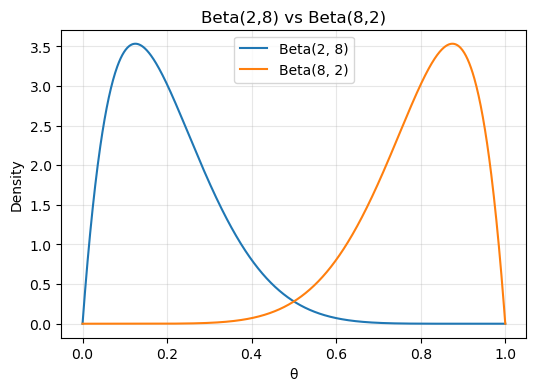

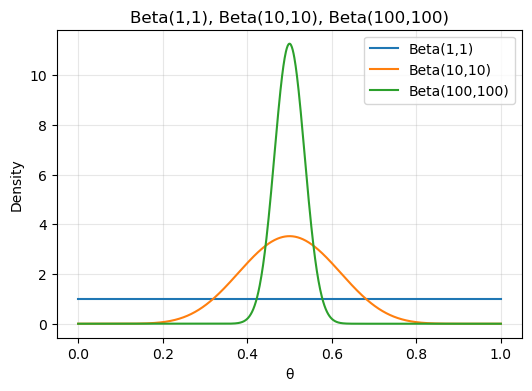

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# x축 범위
x = np.linspace(0, 1, 1000)

# -------------------------------
# 1) Beta(2,8) 과 Beta(8,2)
# -------------------------------
plt.figure(figsize=(6,4))
plt.plot(x, beta.pdf(x, 2, 8), label='Beta(2, 8)')
plt.plot(x, beta.pdf(x, 8, 2), label='Beta(8, 2)')
plt.title('Beta(2,8) vs Beta(8,2)')
plt.xlabel('θ')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -------------------------------
# 2) Beta(1,1), Beta(10,10), Beta(100,100)
# -------------------------------
plt.figure(figsize=(6,4))
plt.plot(x, beta.pdf(x, 1, 1), label='Beta(1,1)')      # Uniform
plt.plot(x, beta.pdf(x, 10, 10), label='Beta(10,10)')
plt.plot(x, beta.pdf(x, 100, 100), label='Beta(100,100)')
plt.title('Beta(1,1), Beta(10,10), Beta(100,100)')
plt.xlabel('θ')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


자 첫번째 그래프를 보죠. 우선 파란색으로 표현된 beta(2,8)의 그래프부터 봅시다. 만약 동전이 앞면이 나올 확률에 대한 사전 분포를 이렇게 잡았다면, 그건 무슨 말일까요? 그 확률이 낮은 쪽으로 생각을 하고 있다는 뜻입니다. 반대로 주황색 선, 즉 beta(8,2)면 큰 쪽으로 생각을 하고 있는 거죠. 이렇게 파라미터 a, b를 조정함으로써, 확률에 대한 내 믿음의 방향을 표현할 수 있습니다. 두 번째 그래프는 모두 대칭적인 분포의 형태를 이루고 있습니다. a와 b의 값을 같게 하면 대칭적인 분포가 나옵니다. 다만 숫자의 크기에 따라 확률 0.5에 대한 자신감이 달라집니다. beta(10,10)과 beta(100,100)은 그 확신의 차이를 차이나게 표현하고 있지요. 

자 이제 베타 분포에 대해 대략 알아봤으니, 이걸 우리가 '동전 앞면이 나올 확률'에 대한 사전 확률 분포를 표현하는 용도로 사용해봅시다. a와 b를 어떻게 설정하면 좋을까요? 우리의 기존 믿음을 반영해야겠지요. 예를 들어 기존에도 실험이 이루어졌는데, 그 전에 20번을 던져봤더니 10번은 앞면이, 10번은 뒷면이 나왔다고 가정합시다. (앞서 말했듯이 이번 실험에는 14번 앞면이, 6번 뒷면이 나왔습니다) 이런 경우 기존의 실험, 즉 과거의 실험 결과를 반영하여 사전 분포를 beta(10,10)으로 삼는 것이 가능할 것입니다. 그러면 첫번째 우리가 필요한, f(동전 앞면이 나올 확률)을 우리는 얻었습니다. 그건 beta(10,10), 즉 $\frac{\Gamma(20)}{\Gamma(10)\Gamma(10)}\theta^{10-1}(1-\theta)^{10-1}$ 입니다. 여기서 $\theta$는 동전이 앞면이 나올 확률이고요. 

자 그럼 다음으로 f(실험 결과|동전이 앞면이 나올 확률)를 구해봅시다. 이건 어떻게 설정하면 될까요? 그건 일단 사전분포로부터 $\theta$가 주어졌다고 가정하고 이항 분포를 활용하면 됩니다. 결국 우리 실험은 동전을 20번 던진 상황, 즉 두 가지 결과를 가진 불확실한 실험의 결과가 20번 반복되어서 쌓인 상황이니까요. 그건 $\binom{20}{14}\theta^{14}(1-\theta)^6$으로 쉽게 표현할 수 있습니다. 

그럼 마지막 f(실험 결과)만 얻으면 되겠네요. 이건 어떻게 할까요? 앞서 질병 사례와 동일하게 접근하면 됩니다. 앞서 양성이 나올 확률, 즉 실험 결과가 나올 확률을 실제 질병이 있는데 양성이 나올 확률에 질병이 없는데 양성이 나올 확률을 더해서 구했죠. 마찬가지입니다. 우리의 관심 대상인 '동전이 앞면이 나올 확률'의 여러 가지 가능성을 가정하고 거기에서 '20번 던졌는데 14번 앞면이 나올 확률'을 구해서 다 더하면 됩니다. 

다만 앞의 질병 사례에서는 관심 파라미터인 '질병 상태'가 딱 두 가지 상태만 있어서 직접적으로 덧셈으로 표현했는데, 지금 경우는 그렇게 하기 힘듭니다. 동전이 앞면이 나올 확률은 연속적으로 존재하니까요. (즉 가짓수가 무수히 많죠) 이럴 경우에 우리는 고등학교에서 배운 적분을 활용하여 표현합니다. 아래처럼요. 

$$
\begin{aligned}
f(data) &= \int_0^1 f(data|\theta)f(\theta)d\theta \\[30pt]
&= \int_0^1 \binom{20}{14}\theta^{14}(1-\theta)^6 \frac{\Gamma(20)}{\Gamma(10)\Gamma(10)}\theta^{10-1}(1-\theta)^{10-1} d\theta \\[30pt]
&=\int_0^1 \binom{20}{14} \frac{\Gamma(20)}{\Gamma(10)\Gamma(10)}\theta^{23}(1-\theta)^{15} d\theta
\end{aligned}
$$

복잡해보이지만, 이건 $\theta$, 즉 동전이 앞면이 나올 확률을 0부터 1까지 변형해가면서 그런 확률이 사전분포에서 나올 확률값과 (사전 확률) 그 확률값에 근거하여 계산된 현 실험의 개연성 혹은 가능도를 (likelihood) 곱해서 다 더하겠다는 말입니다. 

최종적으로 이렇게 정리되는 셈입니다. 우리가 베이즈 정리를 활용하여 동전이 앞면이 나올 확률에 대한 사후 분포를 이렇게 정의했습니다. 

$$
\begin{aligned}
f(동전이 앞면이 나올 확률|실험 결과) &= \frac{f(실험 결과|동전이 앞면이 나올 확률) \times f(동전이 앞면이 나올 확률)}{f(실험 결과)} \\[20pt]
&= \frac{f(data|\theta) \times f(\theta)}{f(data)} \\[20pt]
&= \frac{likelihood \times prior}{evidence} 
\end{aligned}
$$

더불어 베이지안 추론에서는 $f(data|\theta)$ likelihood function으로, $f(\theta)$를 prior probability distibution으로, $f(data)$를 evidence로 가리키는 경우가 많으니 참조하세요. 

이걸 위에서 실제로 얻은걸 가지고 다 이어서 적어보면 이런 긴 수식이 나옵니다. 

$$
\begin{aligned}
f(data|\theta) &= \binom{20}{14}\theta^{14}(1-\theta)^6\\[10pt]
f(\theta) &= \frac{\Gamma(20)}{\Gamma(10)\Gamma(10)}\theta^{10-1}(1-\theta)^{10-1}\\[10pt]
f(data) &= \int_0^1 \binom{20}{14} \frac{\Gamma(20)}{\Gamma(10)\Gamma(10)}\theta^{23}(1-\theta)^{15} d\theta\\[30pt]
\frac{f(data|\theta) \times f(\theta)}{f(data)} &= 
\frac{\binom{20}{14} \frac{\Gamma(20)}{\Gamma(10)\Gamma(10)}\theta^{23}(1-\theta)^{15}}{\int_0^1 \binom{20}{14} \frac{\Gamma(20)}{\Gamma(10)\Gamma(10)}\theta^{23}(1-\theta)^{15} d\theta}
\end{aligned}
$$

이제 이걸 좀 정리해봅시다. 


일단 상수부터 적분 기호에서 빼도록 합시다. 앞서 말한 것처럼 감마 함수, 그리고 combination등은 다 상수입니다. 그럼 이렇게 정리할 수 있죠. 

$$
\begin{aligned}
\frac{\theta^{23}(1-\theta)^{15}}{\int_0^1 \theta^{23}(1-\theta)^{15} d\theta}
\end{aligned}
$$


우리가 난감한 부분은 적분입니다. 저걸 실제로 적분하기는 좀 어렵거든요. 근데 확률 분포 함수라는 점을 사용한 일종의 트릭을 쓸 수 있습니다. 적분 기호 안쪽을 잘 살펴보면 확률 분포 함수를 닮아 있습니다. 베타 분포 함수를 닮아 있지요. 만약 적분 기호 안쪽을 완전한 베타 분포 함수 꼴로 만들면, 적분 결과는 자동으로 1이 됩니다. 확률 분포 함수를 해당 확률 변수값의 모든 가능성에 대해 다 더하면 당연히 1입니다. 그게 확률 분포 함수의 정의죠. 예를 들어 정규 분포 함수를 마이너스 무한대부터 플러스 무한대까지 적분하면 1이 나오는것처럼요. 그래서 우리는 분자와 분모 아래위에 동일한 상수를 곱해주는 트릭을 씁니다. 아래처럼요. 

$$
\begin{aligned}
\frac{\frac{\Gamma(40)}{\Gamma(24)\Gamma(16)}\theta^{23}(1-\theta)^{15}}{\int_0^1 \frac{\Gamma(40)}{\Gamma(24)\Gamma(16)}\theta^{23}(1-\theta)^{15} d\theta}
\end{aligned}
$$

아래 위에 $\frac{\Gamma(40)}{\Gamma(24)\Gamma(16)}$를 곱해주는 것입니다. 이건 복잡해보이지만 결국 상수이기 때문에 적분 기호 안으로도 쉽게 들어갑니다. 곱하고 더하나 더하고 곱하나 그게 그거니까요^^ 그런데 이렇게 되면 이게 뭐가 되는지 잘 보시죠. 적분 기호 안쪽을 잘 보면, 저건 결국 beta(24, 16)의 확률 분포 함수입니다. 그걸 적분하면 뭐가 될까요? 결국 1입니다. 그러면 분모는 자연스럽게 사라집니다. 분자는 뭘까요? 그것도 beta(24, 16)의 확률 분포 함수 꼴을 하고 있습니다. 결국 이건 이런 말입니다. 

$$
\begin{aligned}
\frac{f(data|\theta) \times f(\theta)}{f(data)} = 
\frac{\binom{20}{14} \frac{\Gamma(20)}{\Gamma(10)\Gamma(10)}\theta^{23}(1-\theta)^{15}}{\int_0^1 \binom{20}{14} \frac{\Gamma(20)}{\Gamma(10)\Gamma(10)}\theta^{23}(1-\theta)^{15} d\theta} = Beta(24, 16)
\end{aligned}
$$

이건 좀 신기한 상황입니다. 동전이 앞면이 나올 확률, 즉 $\theta$에 대한 사전 확률 분포를 베타 분포로 (Beta(10, 10))으로 설정하고 들어갔는데, 사후 확률 분포도 베타 분포(Beta(24, 16))가 나왔기 때문입니다. 이는 베타 분포와 이항 분포의 곱이 결국 베타 분포 형태로 귀결되기 때문에 생기는 일입니다. 이런 상황을 표현하기 위해 베이지안 통계에서는 특별한 용어가 있는데, 이런 상황에서 **베타 분포를 이항 분포의 conjugate prior distribution, 켤레 분포 라고 부릅니다.** 사후 분포가 사전 분포와 동일한 형태로 정리되는 것을 표현하고 있습니다. 그래서 이런 경우는 사실 위처럼 길게 수식을 유도할 필요도 없습니다. 사후 분포가 어떻게 나오는지 잘 알려져 있거든요. 그래서 이런 식의 정리가 가능합니다. 

- 만약 사전 분포가 Beta(a, b)이고, 데이터에서 주어진 likelihood function이 성공 x, 실패 n-x로 이루어진 이항 분포함수이면, 사후 분포는 Beta(a+x, b+n-x)를 따른다 

여기서 우리는 Beta 분포에 들어가는 파라미터의 직관적 의미도 대략 알 수 있습니다. 만약 Beta 분포가 모델링하고 있는 것이 어떤 사건의 '확률'이라면, a는 기존 성공 횟수, b는 기존 실패 횟수라고 대략 해석할 수 있습니다. 이걸 새로운 실험을 가지고 갱신하니까, a에 새로운 실험에서 성공 횟수가 더해지고, b에는 새로운 실험에서 실패 횟수가 더해지는거죠. 

자 그러면 우리의 새로운 실험에 근거하여 동전이 앞면이 나올 확률에 대한 믿음의 분포가 어떻게 변했는지 그림으로 알아봅시다. 

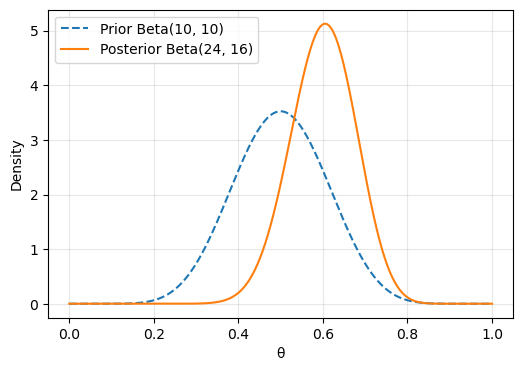

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# x축 범위
x = np.linspace(0, 1, 1000)

# -------------------------------
# 1) Beta(10,10) 과 Beta(24,16)
# -------------------------------
plt.figure(figsize=(6,4))
plt.plot(x, beta.pdf(x, 10, 10), linestyle = '--', label='Prior Beta(10, 10)')
plt.plot(x, beta.pdf(x, 24, 16), label='Posterior Beta(24, 16)')
plt.xlabel('θ')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

즉 점선에서 실선으로 우리의 믿음이 이동했습니다. 앞면이 좀 더 나오는 결과를 얻었으니 그런거죠. 이처럼 베이지안 통계는 관심 파라미터를 random variable로 놓고, 그것에 대한 사전 확률 분포를 가정하고, 데이터를 고려하여 그것을 업데이트합니다. 이 과정에서 사전 분포의 형상, 데이터의 규모와 패턴 등이 영향을 미칩니다. 

예를 들어 앞서와 동일한 실험 결과가 있는데 (즉 20번 던졌는데 14번 앞면, 뒷면 6번), 사전 분포가 beta(10,10)인 상황과 beta(30,30)인 상황을 비교해봅시다. 그러면 사후 분포가 beta(24,16), beta(44, 36)으로 각기 다르게 나오겠지요. 이게 어떤 차이일까요? 아래 코드를 실행시켜보세요. 

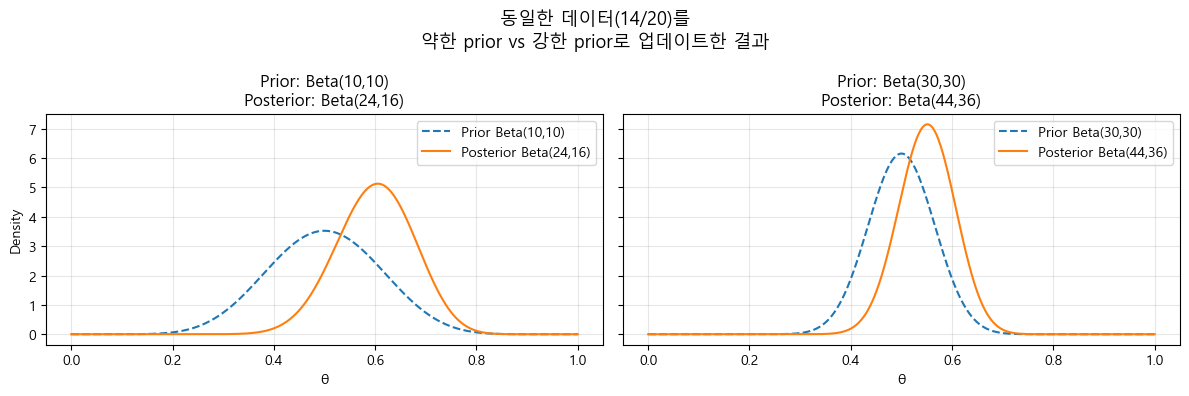

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False 

# x축 범위
x = np.linspace(0, 1, 1000)

# 그림 설정
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# -------------------------------
# 패널 1: Beta(10,10) → Beta(24,16)
# -------------------------------
axes[0].plot(x, beta.pdf(x, 10, 10), linestyle='--', label='Prior Beta(10,10)')
axes[0].plot(x, beta.pdf(x, 24, 16), linestyle='-', label='Posterior Beta(24,16)')
axes[0].set_title('Prior: Beta(10,10)\nPosterior: Beta(24,16)')
axes[0].set_xlabel('θ')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

# -------------------------------
# 패널 2: Beta(30,30) → Beta(44,36)
# -------------------------------
axes[1].plot(x, beta.pdf(x, 30, 30), linestyle='--', label='Prior Beta(30,30)')
axes[1].plot(x, beta.pdf(x, 44, 36), linestyle='-', label='Posterior Beta(44,36)')
axes[1].set_title('Prior: Beta(30,30)\nPosterior: Beta(44,36)')
axes[1].set_xlabel('θ')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('동일한 데이터(14/20)를\n약한 prior vs 강한 prior로 업데이트한 결과', fontsize=13)
plt.tight_layout()
plt.show()


즉 베이지안 분포는 같은 실험 결과라 해도, 사전에 믿음을 어떻게 가졌는가에 따라 사후 분포를 다르게 추론합니다. 예를 들어 beta(30,30)처럼 좀 더 강하게 0.5라는 믿음을 가졌을 때에는 사후 분포도 오른쪽으로 충분히 이동하지 못합니다. 오른쪽 결과를 보면 확연히 왼쪽에 붙어 있죠. 사전적 믿음이 매우 강한 패턴을 가졌기에 많이 이동을 하지 못한 셈입니다. 

더불어 같은 비율의 실험 결과라도 다른 결과를 낳습니다. 예를 들어 MLE에서 동전이 앞면이 나올 확률을 추론하면 200번 중 140번 앞면이 나오나, 20번 중 14번 앞면이 나오나 동일하게 0.7을 최적추정치로 제공합니다. 그런데 베이지안은 그렇지 않습니다. 사전 분포가 beta(10,10)이었으면, 200번짜리 실험은 beta(150, 70)이 되고, 20번 짜리 실험은 beta(24, 16)을 결과로 가지지요. 이 둘은 약간 다른 구조를 가집니다. 아래 코드를 실행시켜 봅시다. 

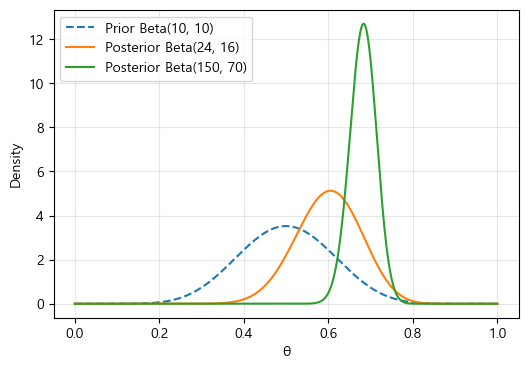

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# x축 범위
x = np.linspace(0, 1, 1000)

plt.figure(figsize=(6,4))
plt.plot(x, beta.pdf(x, 10, 10), linestyle = '--', label='Prior Beta(10, 10)')
plt.plot(x, beta.pdf(x, 24, 16), label='Posterior Beta(24, 16)')
plt.plot(x, beta.pdf(x, 150, 70), label='Posterior Beta(150, 70)')

plt.xlabel('θ')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

어떤가요? 200번짜리 실험은 0.7이라는 MLE의 최적 추정치로 꽤 많이 확신을 갖고 이동하고 있습니다. 여전히 다른 여지를 주고 있지만요. 

지금까지 살펴본 것이 베이지안 추론을 통해 파라미터의 사후 확률 분포를 얻는 가장 기본적인 과정입니다. 

**토픽 모델링도 본질적으로 동일한 과정을 거칩니다.** 추정해야 할 파라미터 숫자가 많고, 사전 분포가 이와 좀 다를 뿐입니다. 그런데 이렇게 하면 뭐가 좋을까요? 그러니까, 관심 파라미터를 확률 변수로 규정하고, 이런 다소 복잡한 과정을 거쳐 그에 대한 확률 분포를 구하는 것이 왜 좋은걸까요? 아래와 같은 장점이 주로 언급됩니다.

1. 사전적 정보를 활용할 수 있습니다. 어떤 현상에 대해 미리 그럴 듯한 지식을 가진 경우가 적지 않습니다. 그걸 무시하고 완전히 데이터에서 나타난 정보만을 믿으면, 경우에 따라서는 문제가 생길 수 있습니다. 데이터가 노이즈가 많거나 부족할 수도 있으니까요. 예를 들어 우리는 인터넷에서 곰이 시장에서 쇼핑하는 사진을 봐도 그걸 쉽게 믿지 않습니다. 데이터만 보는게 아니라 우리 기존 신념을 사용하거든요 (곰은 보통 오프라인 매장에서 쇼핑을 하지 않죠. 온라인 쇼핑은 모르겠습니다만...). 베이지안 추론은 이를 위한 체계적 방안을 제시합니다. 

2. 파라미터의 사후 확률 분포는 파라미터의 점 추정치보다 활용 방안이 많습니다. 예를 들어 동전이 앞면이 나올 확률에 대한 점 추정치가 아니라 분포를 얻었다고 하죠. 그러면 다양한 활용 방안이 있습니다. 예를 들어 파라미터가 0.5보다 클 확률을 계산한다든가 하는 식이죠. 그건 MLE의 점 추정치로는 못하지만, 사후 확률 분포를 얻으면 할 수 있습니다. 좀 더 근본적으로 말해, 만약 사후 확률 분포가 설득력이 있다면, 그래서 해당 파라미터의 '불확실성의 구조'에 대해 정말로 알려주고 있다면, 이것은 분명 점 추정치보다는 다양한 정보를 제공하고 있습니다. 단순히 사후 확률을 최대화하는 파라미터의 값이 뭔지 알려줄 뿐 아니라, 다양한 가능성들이 어느 정도의 확률로 존재하는지 알려주고 있지요. 그래서 이런 확률 분포를 얻으면, 관심 파라미터의 가능성이 하나로 쏠려 있는지 (봉우리가 하나인 형국이죠), 아니면 다양하게 퍼져 있는지 (다수의 봉우리가 있는, 고원 같은 형태겠죠), 퍼져 있으면 얼마나 퍼져 있는지 알 수 있습니다. 그렇기에 우리의 추정치가 얼마나 쓸만한지도 알 수 있지요. 

그리고 앞서 말했듯이 LDA를 제안한 블레이는 토픽 모델링에서 베이지안 추론을 동원한 이유로 '사전 분포가 만들어내는 정규화 효과를 통한 과적합 억제'와 '생성 모델로서의 가능성'을 언급합니다. 

## 6. 문서에의 베이지안 추론의 적용

자 그러면 이런 세계관을 문서 혹은 언어 자료에 대입해 볼 차례입니다. 다만 바로 LDA로 가지는 않겠습니다. LDA가 제시하는 관심 파라미터의 사후 분포로 돌아가기 위해 딱 하나만 더 해보겠습니다. 그건 디리클레 분포를 활용하여 '카테고리 분포'에 대한 사후 확률 분포를 갱신하는 것입니다. 앞선 동전 앞면 나올 확률에 대한 확률 분포 구하기의 일반화라고 볼 수도 있습니다. 

앞서 우리가 살펴본 예는 '동전 앞면이 나올 확률'에 대한 사전 확률 분포를 사후 확률 분포로 업데이트하는 것이었습니다. 그걸 한 까닭은 동전 던지기 실험결과, 즉 확률적 생성 과정을 거쳐 만들어진 데이터를 생성할 법한 확률적 구조를 알고 싶었기 때문입니다. 우리는 이를 위해 '동전이 앞면이 나올 확률'을 알고 싶었고, 베이지안 추론에 따라 그 값에 대한 점 추정치가 아니라 그에 대한 확률 분포를 구했습니다. 그래서 '동전이 앞면이 나올 확률에 대한 확률 분포'를 구했죠. 

이 상황에서는 이것으로 충분했는데, 그것은 동전 던지기라는 실험의 결과가 딱 두 가지로 한정되기 때문입니다. 앞면 아니면 뒷면이죠. 그리고 뒷면의 확률은 앞면의 확률이 알면 바로 정해지기 때문에 따로 구할 필요가 없습니다. 그래서 **'동전이 앞면이 나올 확률에 대한 확률 분포'를 구했다는 말은 '동전을 던진 결과에 대한 확률 분포'를 구했다는 말과 사실 같습니다.** '동전이 앞면이 나올 확률이 0.6일 확률이 0.4다' 라는 말은 '[앞면 - 0.6, 뒷면 - 0.4]라는 방식으로 확률 분포가 주어질 가능성이 0.4다'라는 말과 동일하다는 말입니다. 즉 우리는 동전이 앞면이 나올 확률에 대한 확률 분포를 구했는데, 실험 결과가 2가지 밖에 없는 특성상, 이를 통해 '동전 던지기의 결과의 확률 분포에 대한 확률 분포'를 구한 셈입니다. 

그런데 사실 어떤 불확실한 일의 결과가 혹은 어떤 실험의 결과가 이렇게 딱 두 개인 경우가 오히려 드뭅니다. 주사위 던지기만 해도 그렇지 않죠. 가장 평범한 주사위만 해도, 나올 수 있는 결과가 1에서 6까지 6가지입니다. 더 결과가 많은 경우도 있고요 (8면, 12면 주사위도 있다고 들었습니다).

토픽 모델링이 관심을 가진 확률적 생성, 즉 문서를 확률적으로 생성하는 일은 동전 던지기 보다 주사위 던지기에 가까운 일입니다. 왜냐하면 단어의 종류가 2개 보다 훨씬 많기 때문입니다. 앞서 말한 생성 과정을 거쳐 문서에 들어갈 단어를 만든다고 하면, 그건 문서에 채워넣을 목표 단어 숫자만큼 무수한 면으로 이루어진 주사위, 예컨대 2000개의 면이 있는 주사위를 던지는 일일 겁니다. (보통 기사 정도의 길이가 되는 문서를 1000개만 모아도 거기서 출현하는 단어는 2000개를 훌쩍 넘어가곤 합니다.) 그 주사위의 각 면에는 단어가 적혀 있고요. 그래서 주사위를 던질 때마다 결과로 나오는 단어를 기록해 나가는 것이지요.  

우리가 상상하고 있는 2000면을 가진 주사위는 '단어의 확률 분포'를 물리적으로 구현한 것이라 할 수 있습니다. 단어의 확률 분포란, 서두에 말한 것처럼 [사과 - 0.01, 바나나 - 0.015, 포도 - 0.001,....] 이런 식으로 무수한 단어에 확률을 부여한 것입니다. 카테고리 분포의 일종입니다. 그리고 이 확률 분포를 이루고 있는 단어들 중 하나가 '확률적 단어 생성'의 결과로 도출되는 거죠. 높은 확률을 할당 받은 단어는 등장 횟수가 많을 것입니다. 그렇기에 a bag of words로 정의된 문서가 확률적으로 생성되었다고 가정했을 때 문서를 생성할 법한 확률 구조를 추론한다는 말은, 이런 단어 확률 분포의 형상을 추론한다는 말에 다름 아닙니다. 

그러면 이번에는 이 단어 확률 분포 자체에 대한 사전 확률 분포를 가정하고, 그것을 데이터를 고려하여 사후 확률 분포로 업데이트 할 필요가 있습니다. 앞서 동전 던지기 결과에 적용했던 과정을 그대로 적용하는 것입니다. 구도를 비교하면 다음과 같습니다. 

- 동전 상황
    - 설명하고 싶은, 확률적 생성을 통해 만들어진 데이터: [앞면, 뒷면, 앞면, 앞면, 뒷면,...] / 앞면 14번, 뒷면 7번 / 동전 던지기 실험 결과
    - 이 데이터의 이면에 있는 확률 분포: [앞면 - ?, 뒷면 - ?] / 그런데 이건 앞면 확률만 알아도 자동으로 구해짐
    - 이 확률 분포에 대한 사전 확률 분포 모델링: 베타 분포로 시도 / 앞면 확률에 대한 확률 분포는 곧 [앞면 확률, 뒷면 확률]이라는 확률 분포이며, 이것을 수식화
    - 베이지안 추론의 목표: [앞면 - ?, 뒷면 - ?]의 다양한 상태에 대한 사후 확률 분포 구하기


- 문서 상황
    - 설명하고 싶은, 확률적 생성을 통해 만들어진 데이터: [성장,품질,강조,서프라이즈,부양책,....] / 성장 - 10회, 품질 - 5회, 서프라이즈 - 1회, ..... / a bag of words로 정의된 문서
    - 이 데이터의 이면에 있는 확률 분포: [성장 - ?, 품질 - ?, 강조 - ?, 서프라이즈 -?, ....] / 단어의 확률 분포 / 카테고리 분포
    - 이 확률 분포에 대한 사전 확률 분포 모델링: 디리클레 분포로 시도 / 카테고리 분포 (벡터인데 벡터를 구성하는 각 값이 0과 1사이의 값을 가지고 모든 값을 더하면 1이 되는 특수한 조건을 가진 벡터)에 대한 확률 분포를 수식화
    - 베이지안 추론의 목표: [성장 - ?, 품질 - ?, 강조 - ?, 서프라이즈 -?, ....]의 다양한 상태에 대한 사후 확률 분포 구하기


자 그럼 문서의 예로 본격적으로 들어가봅시다. 아주 단순한 구도의 예를 생각해보겠습니다. 기사가 딱 하나 주어졌다고 하겠습니다. <위고비로 비만 잡는다해도, 우리는 외로워질 것입니다> 라는 제목의 김창엽 교수님 인터뷰 기사입니다. 경향신문 이혜인 기자가 작성하였는데, 일독을 권합니다^^(https://www.khan.co.kr/article/202510210600051) 전체 기사는 좀 기니까, 딱 아래 부분만 주어졌다고 가정하겠습니다. 

    열풍을 넘어 ‘광풍’이다. 기존 비만치료제보다 식욕 억제 효과가 크고 부작용이 적다고 알려진 새로운 치료제의 유행이 거세다. 정상체중인 이들조차 비만치료제 위고비를 싸게 판다는 일명 ‘성지 의원을 찾아 줄을 서 번호표를 받는다. 심지어 어린이와 임산부를 대상으로도 비만치료제가 처방됐고, 정상 체중인 딸에게 엄마가 치료제 투약을 강권한다는 뉴스도 들려온다.

자 이걸 bag of words로 본다는 말은 아래처럼 처리하겠다는 뜻입니다. 그 안에 나온 단어들만 모았습니다. (정확히 말하면 명사만 모은 건데, 그냥 단어라고 칩시다) 총 29개입니다. 

    [열풍,광풍,비만치료제,효과,식욕,억제,부작용,치료제,유행,정상,체중,비만,치료제,위고비,의원,일명,성지,번호표,어린이,임산부,대상,비만치료제,처방,정상,체중,엄마,치료제,투약,강권]

문서를 A bag of words로 보는건, 원리적으로 다양한 버전이 있지만, 토픽 모델링에서는 '종류'와 '빈도'를 모두 보존한 표현을 활용합니다. 그러니 아래와 같은 형상으로 요약할 수 있을 것입니다. 24 종류의 단어가 관찰됩니다. 

    {'치료제': 3, '비만치료제': 2, '정상': 2, '체중': 2, '열풍': 1, '광풍': 1, '효과': 1, '식욕': 1, '억제': 1, '부작용': 1, '유행': 1, '비만': 1, '위고비': 1, '의원': 1, '일명': 1, '성지': 1, '번호표': 1, '어린이': 1, '임산부': 1, '대상': 1, '처방': 1, '엄마': 1, '투약': 1, '강권': 1}

In [5]:
from collections import Counter

doc = ["열풍","광풍","비만치료제","효과","식욕","억제","부작용","치료제","유행","정상","체중","비만",
       "치료제","위고비","의원","일명","성지","번호표","어린이","임산부","대상","비만치료제","처방",
       "정상","체중","엄마","치료제","투약","강권"]

print("전체 단어 숫자: ", len(doc), "\n")
freq = Counter()
freq.update(doc)
print(freq, "\n")
print("단어 종류: ", len(freq))

전체 단어 숫자:  29 

Counter({'치료제': 3, '비만치료제': 2, '정상': 2, '체중': 2, '열풍': 1, '광풍': 1, '효과': 1, '식욕': 1, '억제': 1, '부작용': 1, '유행': 1, '비만': 1, '위고비': 1, '의원': 1, '일명': 1, '성지': 1, '번호표': 1, '어린이': 1, '임산부': 1, '대상': 1, '처방': 1, '엄마': 1, '투약': 1, '강권': 1}) 

단어 종류:  24


자 저것이 데이터입니다. 이것이 '확률적으로 생성되었다'고 생각하는 것은, 이 문서가 24개 면을 가진 (단어가 24 종류니까) 주사위 던지기를 29번 한 결과로 (총 단어가 29개이니까) 가정하는 셈이지요. 그리고 앞서 말씀드렸듯 주사위는 카테고리 분포로 주어진 단어 확률 분포를 형상화한 것입니다. 그러면 우리는 동전이 앞면이 나올 확률에 대한 확률 분포를 데이터를 고려해 추정했듯 단어 확률 분포에 대한 확률 분포를 이 데이터를 고려해 추정해야 합니다. 

그러려면 동전에서 베타 분포와 같은 도구가 필요합니다. 앞서 우리는 동전이 앞면이 나올 확률에 대한 사전적 믿음을 베타 분포로 모델링, 즉 표현하였습니다. 그러면 카테고리 분포의 형상을 가진 단어 확률 분포에 대한 사전적 믿음을 어떻게 표현할까요? 여기서 디리클레 분포가 등장합니다. 디리클레 분포는 베타 분포의 일반적 형태라고 할 수 있는데요, 일단 수식부터 보겠습니다. 

$$
\begin{aligned}
f([\theta_1,\theta_2,\theta_3,\theta_4,\theta_5,...,\theta_k]\mid[\alpha_1,\alpha_2,\alpha_3,\alpha_4,\alpha_5,...,\alpha_k]) =  
\frac{\Gamma(\sum_{i=1}^k\alpha_i)}{\prod_{i=1}^k\Gamma(\alpha_i)}\prod_{i=1}^k \theta_i^{\alpha_i-1}\\[15pt]
0<\theta_i<1, \sum_{i=1}^k \theta_i = 1
\end{aligned}
$$

엄청 복잡해보이는데, 사실 베타 분포의 일반화라는 관점에서 보면 됩니다. 다만 베타 분포에서는 x와 (1-x)만 존재했던 셈이니 (동전 앞면 확률, 뒷면 확률인 셈이죠) 파라미터가 2개였는데, 이번에는 입력 벡터가 가진 구성 요소 개수 만큼 (즉 입력 벡터가 속한 공간의 차원만큼) 파라미터가 필요하고, 동일한 형태로 결합되어 있다고 보면 됩니다. 참조 삼아 베타 분포 확률 함수를 다시 한 번 보여드릴게요. 일반화라고 말씀드리는 이유를 쉽게 이해하실 겁니다. 

$$
f(\theta|a,b) = \frac{\Gamma(a+b)}{\Gamma(a)\Gamma(b)}\theta^{a-1}(1-\theta)^{b-1}, \quad 0<x<1
$$

자 이것도 몇 개 그림을 좀 그려서 감을 잡아볼게요. 

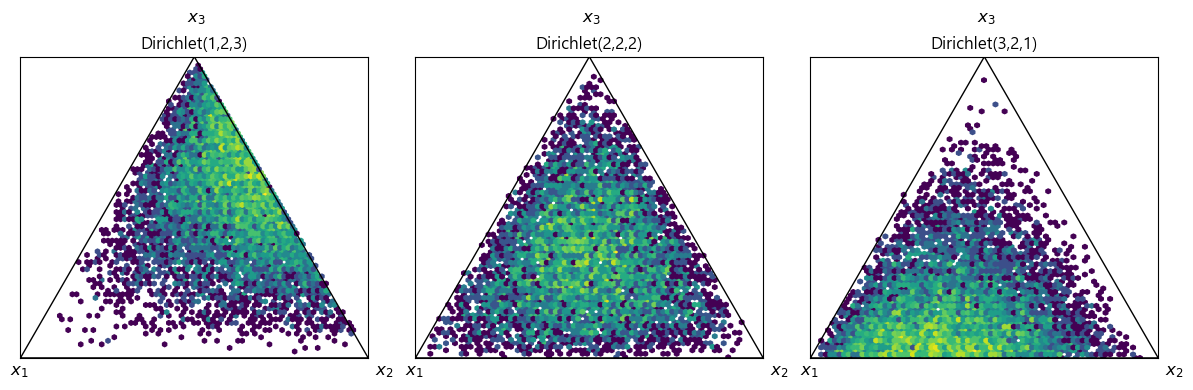

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import dirichlet

# ---------------------------------------
# 1️⃣ 변환 함수: 3차 단순체 -> 2D 좌표로
# (왼쪽 아래 x1, 오른쪽 아래 x2, 위쪽 x3)
# ---------------------------------------
def to_cartesian(x):
    a, b, c = x[:, 0], x[:, 1], x[:, 2]
    X = b + 0.5 * c
    Y = (np.sqrt(3)/2) * c
    return X, Y

# ---------------------------------------
# 2️⃣ 샘플 생성 및 시각화
# ---------------------------------------
alphas = [(1, 2, 3), (2, 2, 2), (3, 2, 1)]
titles = [r'Dirichlet(1,2,3)', r'Dirichlet(2,2,2)', r'Dirichlet(3,2,1)']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, alpha, title in zip(axes, alphas, titles):
    # Dirichlet 샘플
    samples = np.random.dirichlet(alpha, size=8000)
    x, y = to_cartesian(samples)
    
    # 히트맵 (밀도)
    hb = ax.hexbin(x, y, gridsize=70, cmap='viridis', bins='log')
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(0, 1); ax.set_ylim(0, np.sqrt(3)/2)
    ax.set_aspect('equal')

    # 삼각형 외곽선
    triangle = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])
    ax.plot(triangle[:, 0], triangle[:, 1], color='black', lw=1)

    # 꼭짓점 라벨
    ax.text(-0.03, -0.05, r'$x_1$', fontsize=12, fontweight='bold')
    ax.text(1.02, -0.05, r'$x_2$', fontsize=12, fontweight='bold')
    ax.text(0.48, np.sqrt(3)/2 + 0.1, r'$x_3$', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


디리클레 분포가 다루는 벡터의 성분 개수가 많아질수록 (그러니까 고차원 공간의 벡터일수록) 시각화가 어렵습니다. 그래서 딱 세 개의 값만 있다고 하겠습니다. 그걸 [x1, x2, x3] 라고 합시다. 그리고 x1+x2+x3는 1이 되고, 각 값은 0과 1 사이의 값인 조건이 있습니다. 이에 대한 확률 분포라 하면, [0.1, 0.1, 0.8]일 확률 얼마, [0.2, 0.3, 0.5]일 확률 얼마, 뭐 이런 식으로 값을 주는 확률 분포 함수가 있는 것이지요. 

위의 그림이 그런 벡터에 대한 확률 분포를 시각화한 사례입니다. 그림이 좀 생소하실텐데, 삼각형의 각 꼭지점으로 다가갈 수록, 해당 꼭지점에 해당하는 값이 1이 되고 나머지는 0이 되는 위치라고 생각하시면 됩니다. 즉 x3로 표시된 꼭지점에 점을 찍으면, 그건 [0,0,1]처럼 값을 표현하는 방법이 됩니다. 지금 이 그림은 각 분포마다 8000개의 값을 무작위 생성해서 표현한 건데, 더 많은 데이터 포인트가 찍힐 수록 밝게 표현되고 있습니다. 이 두 가지 사항을 염두에 두시면 그걸 염두에 두시면 각 분포가 어떤 형상인지 쉽게 이해가 되실 겁니다. 

Dirichlet(1,2,3), 즉 파라미터를 [1,2,3]으로 준 경우에, X3와 X2 가운데 쯤 (하지만 X3에 더 가깝고 X1에서는 먼) 영역에 점이 많이 찍힙니다. X3에 큰 값을 할당할 가능성이 큰 거죠. Dirichlet(3,2,1)은 반대로 X1에 큰 값을 할당할 가능성이 큰 국면을 보여주고 있습니다. Dirichlet(2,2,2)은 공평하게 세 값이 비슷할 확률이 가장 크게 보는거죠. 

이걸 단어 확률 분포에 대한 사전 확률 분포로 당연히 삼을 수 있습니다. 각 벡터가 특정 단어의 출현 확률이라고 보면 되니까요. 즉 [위고비 - 0.1, 체중 - 0.1, 처방 - 0.8]의 확률이 어느 정도고, [위고비 - 0.2, 체중 - 0.3, 처방 - 0.5]의 확률이 어느 정도고, 이런 식으로 설정하면 되니까요. 그리고 우리가 할 일은, 이걸 세 개의 단어로 이루어진 단어 확률 분포에서 위의 예에서 나온 24개의 단어로 이루어진 단어 확률 분포로 확장하는 것입니다. 그건 디리클레 분포 안에서 쉽게 됩니다. 파라미터를 24개의 값으로 이루어진 벡터로 삼으면 되지요. 즉 디리클레 분포는 24개의 값으로 이루어진 벡터에 대한 확률 분포를 모델링하는데 유용합니다. 

자 그러면 앞에서 처럼 베이즈 정리에 따른 수식을 써놓고 하나하나 채워봅시다. 베이즈 정리는 이러했습니다. 

$$
f(\theta|data) = \frac{f(data|\theta) \times f(\theta)}{f(data)}
$$

이걸 지금 문서 상황에 대응하면 이렇습니다. 우리에게 데이터는 문서고, 추정하려는 파라미터는 단어의 확률 분포이지요. 

$$
f(단어의 확률 분포|문서) = \frac{f(문서|단어의 확률 분포) \times f(단어의 확률 분포)}{f(문서)}
$$

그런데 f(단어의 확률 분포)는 디리글레 분포로 모델링 하기로 했습니다. 앞의 예에서 단어의 종류가 24개였으니, 24개의 값으로 이루어진 벡터를 파라미터로 입력해야 합니다. 일단 사전 분포 형상을 정하고 가야하니까요. 그걸 [2,2,2,2,2,....,2]로 하겠습니다. 즉 모든 자리에 2를 넣겠습니다. 이건 앞서 봤듯이 24개 단어의 확률 값이 모두 동일할 가능성이 상대적으로 크다는 약한 믿음을 표현하고 있습니다. 그러면 사전 확률 분포는 이렇게 표현됩니다. 

$$
f(단어의 확률 분포) = \frac{\Gamma(\sum_{i=1}^{24} 2)}{\prod_{i=1}^{24}\Gamma(2)}\prod_{i=1}^k \theta_i
$$

알파들이 들어갈 자리에 모두 2가 들어갔다고 보면 됩니다. 그러면 이제 우도 함수, f(문서|단어의 확률 분포)가 필요합니다. 이건 다항 분포 함수로 표현할 수 있습니다. 아래와 같이 표현됩니다. 구체적으로 실험 결과가 아래와 같았다는 점을 기억합시다. 

    {'치료제': 3, '비만치료제': 2, '정상': 2, '체중': 2, '열풍': 1, '광풍': 1, '효과': 1, '식욕': 1, '억제': 1, '부작용': 1, '유행': 1, '비만': 1, '위고비': 1, '의원': 1, '일명': 1, '성지': 1, '번호표': 1, '어린이': 1, '임산부': 1, '대상': 1, '처방': 1, '엄마': 1, '투약': 1, '강권': 1}

$$
\frac{29!}{3!\times2!\times2!\times2!\times1!...1!}\theta_1^3\times\theta_2^2\times\theta_3^2\times\theta_3^2....\theta_{24}^1
$$

위처럼 표현할 수 있는 것은, 다항 분포에서 나오는 당연한 귀결입니다. 앞에 있는 $\frac{29!}{3!\times2!\times2!\times2!\times1!...1!}$ 파트는 24가지 구분되는 사건이 발생하는 순서의 경우의 수를 계산한 것입니다. 이항 분포에서 combination 값에 해당하죠. 뒤에 나오는 세타들의 연쇄는 각 사건이 몇 번 발생했는지, 이 경우에는 각 단어들이 몇 번 등장했는지 표현하고 있습니다. 세타1은 치료제의 확률로 가정되었는데, 그게 3번 등장했다, 이런 이야기죠. 

자 이번에는 베타 분포 - 이항 분포 관계처럼 일일이 수식을 전개하지 않겠습니다. 이미 잘 알려져 있는 사실이 있습니다. 베타 분포가 이항 분포의 켤레 사전 분포였듯, 디리클레 분포는 다항 분포의 켤레 사전 분포입니다. 

위에 제시된 f(단어의 확률분포)와 f(문서|단어의 확률 분포)가 곱해졌다고 생각해보세요. 그럼 상수 다 제외하면 세타 곱의 연쇄만 남을 겁니다. 나머지 상수 파트를 잘 조정해주면, 결국 이 경우 $\frac{f(data|\theta) \times f(\theta)}{f(data)}$는 디리클레 분포의 형태로 변화합니다. 

어떤 디리클레 분포 형태로 변화할까요? 앞서 베타 분포가 변화한 방식과 동일합니다. 베타 분포는 원래 Beta(a,b) 였다가, Beta(a+성공 횟수, b+실패 횟수)로 변화했었죠? 디리클레 분포도 마찬가지입니다. 그건 Dirichlet(a1,a2,a3...)였다가, 각 위치에 해당하는 사건, 이 경우에는 각 단어의 출현 횟수를 더해서 갱신됩니다. 우리 데이터를 적용하자면 원래는 Dirichlect(2,2,2,...2) 였다가, Dirichlet(2+3, 2+2, 2+2, 2+2, 2+1, 2+1,....2+1)로 갱신된다는 말입니다. 

이렇게 우리는 '우리에게 주어진 문서와 우리의 사전적 믿음을 고려했을 때, 이 문서를 생성해 낼 법한 단어 확률 분포에 대한 사후 확률 분포'를 얻을 수 있습니다. 

이 과정을 굳이 보여드린 것은, 문서에 대한 베이지안 추론의 적용은, 근본적으로 동전 던지기 결과에 대한 적용과 다르지 않다는 점을 말씀드리기 위함입니다. 다만 사건의 가짓수가 많아진 것 뿐이지요. 단어의 종류가 사건의 가짓수이고, 단어의 갯수는 실험의 횟수라고 보면 될 것입니다. 

## 7. LDA 도식 재확인과 사후 분포 근사라는 문제

### 7.1. LDA 생성 도식 재확인

우리는 6절에서 문서를 단어 확률 분포로 만드는 상황에서 단어 확률 분포에 대한 사후 분포 추론까지 살펴봤습니다. 그럼 이제 토픽 모델링을 할 수 있는 것일까요? 즉 데이터를 고려해서 토픽과 토픽 분포들에 대한 사후 확률 분포를 얻고, 그것에 근거하여 토픽과 토픽 분포들을 잘 추정할 수 있게 된 것일까요? 그런데 아직 갈 길이 멉니다. 위에서 한 문서 적용은 매우 간단한 구도를 가정했습니다. 문서가 딱 하나의 단어 확률 분포에서 나온다고 봤으니까요. 그런데 LDA는 이보다 훨씬 복잡합니다. 

1. 토픽, 즉 단어 확률 분포가 여러 개입니다. 
2. 문서 마다 토픽의 비중 조합, 즉 토픽의 확률 분포가 제각각입니다.
3. 이 때문에 각 단어마다 소속 문서의 토픽 확률 분포를 고려하여 토픽을 할당해야 합니다. 

이 때문에 추정해야 하는 파라미터가 앞서 나온 예에서처럼 <단어의 확률 분포 한 개>가 아니라 <단어의 확률 분포(토픽) 여러개> + <문서 별 토픽 확률 분포들> + <단어 별 토픽 할당>이 됩니다. 

아직 익숙치 않으실테니, 다시 한 번 LDA가 가정하는 문서 생성 도식과 그것에 근거한 추론 목표를 확인해봅시다. 우리는 이 그림에서 출발하였습니다. 

<div style="text-align:center;">
    <img src="_static/figures/lda베이지안 네트워크.jpg" width="600">
</div>

    Blei, D. M., & Lafferty, J. D. (2009). Topic models. Text mining: classification, clustering, and applications, 10(71), 34. 논문에 나온 이미지를 조원광이 다시 그리고 설명을 추가하였습니다. 

이제 '디리클레 분포'는 물론 '사전 확률 분포'라는 개념에 대해서 전보다 익숙해지셨을 것이라 짐작합니다. 저 그림이 의미하는 바도 좀 더 명확해 지셨을 것입니다. 말씀드렸듯이 저 그림은 LDA가 가정하는 문서 생성 도식입니다. 이걸 말로 한 번 정리해보겠습니다. 

1. 일단 토픽 K개를 확률적으로 생성해 냅니다. 샘플링 한다고 표현해도 됩니다. 그걸 $\eta$라는 벡터를 파라미터로 가진 디리클레 분포에 기반해서 합니다.
    - 토픽은 단어의 확률 분포이고, 단어의 확률 분포는 근본적으로 카테고리 분포입니다.
    - 그런데 이 카테고리 분포 자체가 불확실한 값이지요. 어휘의 종류는 정해져 있지만, 그 각각에 어떤 확률이 부여될지 확실하지 않습니다.
    - 이런 '불확실한 확률 분포'의 불확실성을 모델링하는 대표적인 방법이 디리클레 분포라고 말씀드렸습니다. 그래서 이 경우에도 디리클레 분포가 활용됩니다.
        - 다시 한 번 말하지만, 디리클레 분포는 [1번 단어 확률 얼마, 2번 단어 확률 얼마,...]와 같은 벡터에 확률을 부여하는 분포입니다. 그러니 이로부터 확률적으로 단어 확률 분포를 만들 수 있는 거지요.
    - 요컨대 $\eta$라는 벡터를 파라미터로 가진 디리클레 분포로부터 구체적인 토픽 K개가 나옵니다.
2. 다른 한 편, 각 문서마다 '토픽의 확률 분포'도 필요합니다. 이것의 확률적 생성은 $\alpha$라는 벡터를 파라미터로 가진 디리클레 분포에 기반해서 합니다.
    - 문서마다 존재하는 토픽의 확률 분포는 예컨대 [1번 토픽 비중 얼마, 2번 토픽 비중 얼마...] 이런식입니다. 이것도 근본적으로 카테고리 분포지요.
    - 이 역시 '불확실한 카테고리 분포'이기 때문에 디리클레 분포로 모델링하고 있는 것입니다.
    - 문서 개수만큼 토픽의 확률 분포가 필요합니다. 문서마다 고유한 분포가 있어야 하기 때문입니다. 그래서 문서 개수만큼 확률적 생성이 일어납니다.
    - 여기에 더해 문서의 길이도 확률적으로 생성한다고 보는 경우가 있는데, 여기서는 그냥 문서의 길이 (즉 문서에 포함된 단어의 숫자)는 주어졌다고 가정하겠습니다.
    - 이 상태가 되면 문서에 존재하는 각 단어에 토픽을 할당할 수 있습니다. 이미 만들어진 문서별 토픽의 확률 분포에 기반해서 말이죠.
        - 예를 들어 어떤 특정 문서의 토픽 확률 분포가 [1번 토픽 - 10%, 2번 토픽 - 80%, 3번 토픽 - 10%]로 생성되었다면, 그 문서 안에 존재하는 단어들에는 십중 팔구 2번 토픽이 할당될 것입니다.
    - 이렇게 모든 단어에 토픽이 할당되었다고 가정합시다. 그러면 이제 정말 구체적인 단어가 무엇인지 결정할 수 있게 됩니다. 그 특정 토픽에서 실제 단어를 뽑아내면 되죠.
        - 지금 단어에 토픽이 할당되었다는 말은, 아직 정해지지 않은 어떤 단어에 토픽만 할당된 것입니다. 예를 들어 '2464번째 문서 21번째 단어에 4번 토픽이 할당되었다'는 식이죠. 실제 그 단어가 뭔지는 모릅니다.
        - 이 네 번째 토픽이라는 단어의 확률 분포가 이렇게 나왔다고 합시다 [사과 - 0.89, 오랜지 - 0.05,...] 편의상 고확률 단어부터 정렬해서 표현하였습니다. 여기서 실제 단어를 확률적으로 생성하면, 역시 십중 팔구 '사과'가 되겠지요.
        - 이 과정을 모든 단어에 대해 반복할 수 있습니다.
    - 이렇게 하면, 모든 문서 모든 단어의 형상을 확정할 수 있겠지요.
    - **이것이 저 그림이 표현하고 있는 생성 과정입니다.**

요컨대, LDA는 두 종류의 디리클레 분포를 사전 분포로 삼아 순차적인 과정을 거쳐 문서를 생성한다고 가정합니다. 그리고 유일한 관찰 가능한 자료인 실제 단어를 단서로, 중간에 핵심 생성 역할을 맡고 있는 '토픽', '문서별 토픽 분포', '단어별 토픽 할당'을 통계적으로 추정하려고 하지요. 처음에 말씀드린 것처럼 이것이 실제 문서 생성 과정을 '정확히' 보여준다고 할 수는 없지만, 나름 괜찮은 근사 생성 과정이고, 이 통계 추론 과정을 통해 얻어진 결과물이 연구에 유용합니다. 

### 7.2. LDA 추론 목표 수식화

자 그래서 이제 우리의 목표는 '주어진 단어를 고려했을 때, 그럴 듯한 토픽, 문서별 토픽 분포, 단어별 토픽 할당이 무엇인지' 알아내는 것입니다. 그리고 베이지안 추론은, 이를 '토픽, 문서별 토픽 분포, 단어별 토픽 할당' 조합에 대한 '사후 확률 분포'를 구해내는 방식으로 접근합니다. 앞서 여러 예에서 봤듯이, 그렇게 하면 목표 파라미터에 대한 여러 정보를 얻을 수 있고, 그래서 좋은 추론을 할 수 있다고 보는 것입니다. 

이걸 수식으로 표현하면 아래와 같이 됩니다. 이것이 우리가 궁극적으로 얻고 싶은 것입니다. 

$$
\begin{aligned}
P(\theta_{1:D}, Z_{1:D}, \beta_{1:K}|W_{1:D}, \alpha, \eta) = \frac{P(W_{1:D}| \theta_{1:D}, Z_{1:D}, \beta_{1:K}) \times P(\theta_{1:D}, Z_{1:D}, \beta_{1:K} | \alpha, \eta)}{P(W_{1:D})}
\end{aligned}
$$

자 그런데 위에 있는 건 사실상 선언에 가깝죠. 좀 더 전개를 해야 내용이 드러납니다. 그럼 어떻게 전개할 수 있을까요? 우선 분자부터 살펴보겠습니다. 일단 그냥 한 번 써볼게요

#### 7.2.1. 분자 파트 전개

$$
\begin{aligned}
&P(W_{1:D} \mid \theta_{1:D}, Z_{1:D}, \beta_{1:K}) \times P(\theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid \alpha, \eta) \\[15pt]
&= P(W_{1:D}, \theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid \alpha, \eta) \\[15pt]
&= P(\beta_{1:K} \mid \eta)P(\theta_{1:D} \mid \alpha)P(Z_{1:D} \mid \theta_{1:D})P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})\\[15pt]
&= \prod_{k=1}^KP(\beta_k \mid \eta)\prod_{d=1}^D\Bigg[P(\theta_d \mid \alpha)\prod_{n=1}^{N_d}\Big(P(Z_{d,n} \mid \theta_d)P(W_{d,n} \mid \beta_{Z_{d,n}})\Big)\Bigg]
\end{aligned}
$$

*여기서 $N_d$는 문서 $d$의 길이를 의미하며, $W_{1:D}=\{W_{d,1:N_d}\}_{d=1}^D$, $Z_{1:D}=\{Z_{d,1:N_d}\}_{d=1}^D$로 문서마다 토큰 수가 다를 수 있음을 전제합니다.*

일단 첫 줄의 수식이 두 번째 줄로 바뀌는 건, 즉 likelihood와 prior를 곱한 것이 결합 확률 분포로 바뀌는 것은, 조건부 확률의 공식입니다. $P(a,b) = P(a|b) \cdot P(b)$를 활용한 것이지요. 

두 번째 줄에서 세 번째 줄과 네 번째 줄로 가는 파트가, 사실 당연한 수학적 내용이라기보다 LDA의 생성 모형 때문에 가능한 진행입니다. 계속봐서 좀 지겨우시겠지만, 다시 한 번 그림을 봅시다. 

<div style="text-align:center;">
    <img src="_static/figures/lda베이지안 네트워크.jpg" width="600">
</div>

    Blei, D. M., & Lafferty, J. D. (2009). Topic models. Text mining: classification, clustering, and applications, 10(71), 34. 논문에 나온 이미지를 조원광이 다시 그리고 설명을 추가하였습니다. 

앞에서 이 그림을 그저 순차적인 방식으로 잠재 변수와 단어가 생성되는 과정 정도로 설명드렸는데, 사실 이 그림은 여러 잠재 변수들 사이의 독립 혹은 조건부 독립을 표현하고 있습니다. 예를 들어 $\alpha$는 $\beta$, 즉 토픽에 전혀 영향을 미치지 않습니다. 당연합니다. 문서별 토픽 분포의 사전 분포 파라미터가 토픽에 영향을 미칠 일이 없죠. $\eta$도 $\theta$에 영향을 미치지 않습니다. 이 역시, 토픽의 사전 분포가 문서별 토픽 분포에 영향을 미칠 일이 없습니다. 나아가 Z가 주어진 상태라면, W는 $\theta$와도 독립입니다. 즉, 이미 단어에 토픽이 할당되었다면, 그 단어가 소속된 문서의 토픽 분포가 어떠한지는 사실 이제 별 영향이 없습니다. 즉, 조건부 독립 관계도 있죠. 

이게 뭐가 그리 중요한가 싶으시겠지만, 이는 변수간 의존 관계를 단순화하는 핵심 정보입니다. 그런 정보를 주는 위의 그림을 '베이지안 네트워크'라고 이름을 따로 붙여서 표현하기도 하죠. 이게 있어서 사실 아래처럼 전개할 수 있었던 것입니다. 
$$
\begin{aligned}
P(W_{1:D}, \theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid \alpha, \eta) = P(\beta_{1:K} \mid \eta)P(\theta_{1:D} \mid \alpha)P(Z_{1:D} \mid \theta_{1:D})P(W_{1:D} \mid Z_{1:D}, \beta_{1:K})
\end{aligned}
$$ 

즉 둘째 줄에서 셋째 줄로 넘어갈 수 있었죠. 반면 정석대로 다 펼쳐버리면, chain rule을 활용해서 이렇게 쓸 수 밖에 없습니다. 

$$
\begin{aligned}
P(W_{1:D}, \theta_{1:D}, Z_{1:D}, \beta_{1:K} \mid \alpha, \eta) = P(\beta_{1:K} \mid \alpha, \eta)P(\theta_{1:D} \mid \beta_{1:K}, \alpha, \eta)P(Z_{1:D} \mid \theta_{1:D}, \beta_{1:K}, \alpha, \eta)P(W_{1:D} \mid Z_{1:D}, \theta_{1:D}, \beta_{1:K}, \alpha, \eta)
\end{aligned}
$$


그런데 생성 모형이 가정한 독립과 조건부 독립을 보니, 일단 정석으로 펼친 항에서 토픽은 $\alpha$에 의존하지 않으니, 그걸 빼도 됩니다. 두 번째 항에서 문서별 토픽 분포 ($\theta$)는 토픽($\beta$)과 토픽의 사전 분포 파라미터($\eta$)와 아무 상관없으니, $\beta, \eta$도 빠지죠. 뒤도 마찬가지입니다. 즉 정석적으로 전개하면, 모든 변수가 모든 변수에 의존할 수 있으니 그걸 다 고려해야 하는데, LDA의 생성 모형이 여러 변수의 독립 관계와 조건부 독립 관계를 표현하고 있기에, 꽤나 단순하게 쓸 수 있는 것입니다. 

그 결과 나온 마지막 줄이 이랬습니다. 

$$
\begin{aligned}
\prod_{k=1}^KP(\beta_k \mid \eta)\prod_{d=1}^D\Bigg[P(\theta_d \mid \alpha)\prod_{n=1}^{N_d}\Big(P(Z_{d,n} \mid \theta_d)P(W_{d,n} \mid \beta_{Z_{d,n}})\Big)\Bigg]
\end{aligned}
$$

이건 위에서 조건부 독립을 고려하여 단순화된 표현을 토큰, 문서, 토픽이 여러 개 있다는 점을 살려서 좀 더 자세하게 쓴 것입니다. 

항목을 앞에서 부터 살펴봅시다. $P(\beta_k|\eta)$는 디리클레 분포에 특정 하이퍼 파라미터가 ($\eta$) 주어졌을 때 만들어진 사전 확률 분포에서 특정한 형태의 토픽 (여기서는 베타 k)가 출현할 확률을 의미합니다. 즉, 분석자가 가정한 토픽에 대한 사전 확률 분포에서 특정한 형태의 토픽이 출현할 확률이죠. 그걸 지금 우리가 가정한 K 개의 토픽에 대해 다 구하고, 그걸 다 곱했다는 뜻이죠. 

거기다가 문서별로 대괄호 안 수치를 문서에 따라 계산해서 다 곱해서 다시 곱합니다. 문서 단위로 어떤 일이 일어나는지 볼까요. 우선 $P(\theta_d|\alpha)$는 디리클레 분포에 특정 하이퍼 파라미터가 ($\alpha$) 주어졌을 때 거기서 d번째 문서에서 가정된 특정 토픽 분포가 출현할 확률을 뜻합니다. 그걸 일단 놔두고, 문서 안에 단어 하나하나 마다 그 다음의 $\prod$ 기호 안쪽의 값들을 다 구해서 또 다 곱하는 겁니다. 

그 안쪽에는 뭐가 있나요? $\theta_d$를 가정한 상태에서 각 단어마다 토픽이 할당되었습니다. 그게 $P(Z_{d,n}|\theta_d)$라는 확률로 표현되고 있습니다. 즉 지금 설정한 토픽 할당이 역시 우리가 가정한 특정 토픽 분포에서 나올 확률이죠. 그런 다음, 특정 단어가 특정 토픽에서 출현했다고 가정할 때, 그 특정 단어가 그 특정 토픽에서 출현할 확률을 계산합니다. 그게 $P(W_{d,n}|\beta_{Z_{d,n}})$로 표현되고 있습니다. 이걸 모든 단어에 대해 다 곱하고, 그렇게 구해진 문서의 확률을 또 문서마다 다 구해서 다 곱하고, 거기에 다가 각 토픽이 출현할 확률을 다 곱한 것을 또 다시 곱해주는 것이죠. 

그래서 이것이 **특정하게 토픽, 문서별 토픽 분포, 단어별 토픽 할당이 가정된 상태에서 우리가 보고 있는 이 데이터가 출현할 확률**이 되는 것입니다. 이까지가 바로 분자의 내용입니다. 

#### 7.2.2. 분모 파트 전개

자 그럼 이제 최초 수식의 분모를 어떻게 계산할까요? 최초 수식은 아래와 같았습니다. 

$$
\begin{aligned}
P(\theta_{1:D}, Z_{1:D}, \beta_{1:K}|W_{1:D}, \alpha, \eta) = \frac{P(W_{1:D}| \theta_{1:D}, Z_{1:D}, \beta_{1:K}) \times P(\theta_{1:D}, Z_{1:D}, \beta_{1:K} | \alpha, \eta)}{P(W_{1:D})}
\end{aligned}
$$

여기서 우리는 분모, $P(W_{1:D})$를 얻고 싶습니다. 그건 아래와 같이 얻을 수 있습니다. 

$$
\begin{gathered}
P(W_{1:D}) = \\[15pt]
\int_{\beta}\int_{\theta}\sum_{Z}P(W_{1:D}, \theta_{1:D}, Z_{1:D}, \beta_{1:K} | \alpha, \eta) = \\[15pt]
\int_{\beta}\int_{\theta}\sum_{Z}\prod_{k=1}^KP(\beta_k|\eta)\prod_{d=1}^D[P(\theta_d|\alpha)\prod_{n=1}^{N_d}P(Z_{d,n}|\theta_d)P(W_{d,n}|\beta_{Z_{d,n}})]
\end{gathered}
$$

즉 이건, 모든 토픽/토픽분포/단어할당의 가능성 조합에 대해서 분자에 해당하는 값을 구해서 다 더하겠다는 것입니다. 왜 이런 방식을 적용하는지 그 정당성은 앞서 질병 사례와 동전 던지기 등에서 이미 다 설명드렸습니다. Law of total probability를 적용한 건데, '양성일 확률'을 계산하기 위해 질병이 있는데 양성이 나올 확률과 질병이 없는데 양성이 나올 확률을 구했던 것을 떠올려 보세요. 즉 지금 우리에게 주어진 데이터가 출현할 확률을, 우리의 관심 파라미터들이 A라는 방식으로 세팅된 상태에서 그 데이터가 출현할 확률과 B라는 방식으로 세팅된 상태에서 그 데이터가 출현할 확률과, C, D....등 가능한 모든 상태에서 그 데이터가 출현할 확률을 다 더하면 나온다는 거죠. 그걸 지금 수식으로 선언한 것입니다. 두 개의 적분 기호와 한 개의 시그마 기호를 가지고 말이죠. (토픽과 토픽 분포의 형태의 가능성은 연속적이고, 단어 할당은 엄청 가짓수가 많지만 결국 정해진 가짓수를 가진 불연속성이 있기에 이렇게 표현됩니다.)

#### 7.2.3. 종합과 사후 분포 근사 문제

그럼 전부 다 종합해 보면, LDA가 추론하려는 관심 파라미터들의 사후 확률 분포는 아래와 같이 표현할 수 있습니다. 

$$
\begin{aligned}
P(\theta_{1:D}, Z_{1:D}, \beta_{1:K}|W_{1:D}, \alpha, \eta) &= \frac{P(W_{1:D}| \theta_{1:D}, Z_{1:D}, \beta_{1:K}) \times P(\theta_{1:D}, Z_{1:D}, \beta_{1:K} | \alpha, \eta)}{P(W_{1:D})}\\[15pt]
&= \frac{\prod_{k=1}^KP(\beta_k \mid \eta)\prod_{d=1}^D\Bigg[P(\theta_d \mid \alpha)\prod_{n=1}^{N_d}\Big(P(Z_{d,n} \mid \theta_d)P(W_{d,n} \mid \beta_{Z_{d,n}})\Big)\Bigg]}{\int_{\beta}\int_{\theta}\sum_{Z}\prod_{k=1}^KP(\beta_k \mid \eta)\prod_{d=1}^D\Bigg[P(\theta_d \mid \alpha)\prod_{n=1}^{N_d}\Big(P(Z_{d,n} \mid \theta_d)P(W_{d,n} \mid \beta_{Z_{d,n}})\Big)\Bigg]}
\end{aligned}
$$

이 수식이 의미하는 바는 뭘까요? 이건 특정 관심 파라미터 세트의 확률을 계산해주는 함수입니다. 즉 데이터를 고려한 상태에서, 우리의 관심 파라미터가 특정한 형태로 조성되었을 때 그것의 개연성을 판단하게 해주는 핵심 결과이죠. 

자 여기서 베이지안 추론을 통한 토픽 모델링이 가진 핵심적 문제가 등장합니다. **이 사후 확률 분포 도식이 계산이 안됩니다. 적을 수는 있는데, 그것으로부터 정보를 이끌어내기가 거의 불가능합니다. 특히 분모 파트가 문제입니다. 분모 파트는, 영어로 말하면 intractable합니다.** 일단 적분하는 것 자체가 상당히 어려운 문제입니다. 지금 주어진 수식 정도면 해석적으로 푸는건 불가능합니다. 여러 변수들이 결합되어 있고, 토픽과 토픽 분포는 너무 차원이 높은 연속 벡터의 적분이 필요하고, 단어 할당도 원칙적 조합이 너무 많아요. 지금 수식이 생각보다 간단하게 적혀 있다고 생각하시는 분이 계실 수도 있는데, 사실 지금 저 수식 표현은 매우 압축해 놓은 것입니다. 예를 들어 $P(\theta_d|\alpha)$ 이런건 원래 디리클레 분포 함수로 표현해야 하니까요. 지금 보기보다 훠~얼씬 복잡합니다. 거기에 심지어 그걸 적분하라고 하고 있는 거죠. 

그래서 이 분모를 못구하면 어떻게 될까요? 그럼 우리의 관심 파라미터의 사후 확률 분포 자체를 구할 수 없게 됩니다. 곤란합니다. 왜냐하면 관심 파라미터의 사후 확률 분포를 구하겠다는 것이 LDA의 핵심 컨셉이었고, 그걸 하면 과적합도 방지하고 생성 모델도 될 수 있고 해서 좋다는게 핵심 주장이었거든요. 이걸 못하는 겁니다. 앞에서의 두 가지 단순한 예에서는 이게 쉽게 풀렸습니다. 동전 앞면 나올 확률의 사후 분포를 구할 때도 그랬고, 단어 확률 분포의 사후 분포 구할 때도 쉽게 분모를 구하고 사후 분포를 특정했습니다. 그런데 이건 사실 켤레 사전 분포를 이용했기 때문에 가능했던 일입니다. 지금은 그게 불가능합니다. 여러 개의 파라미터가 결합을 하고 있거든요. 

**LDA 등이 여기서 택하는 것은 포기가 아니라 근성, 아니 근사(approximation)입니다.** 일단 사후 분포가 수식 상 선언은 될 수 있습니다. 문제는 저게 실제로 어떤 특성을 가진 분포인지 수식으로부터는 알기가 어렵다는 거죠. 그럼 정확하지는 않지만 대략적으로나마 이런 복잡한 사후 분포의 속성을 알아내면 어떨까요? 사실 베이지안 통계에서 사후 확률 분포가 너무 복잡해서 그것이 가진 특성을 근사적으로 알아내려는 시도는 꽤 많이 존재해왔습니다. 그걸 위한 방법도 나름 분류가 되어 있고 각 영역에 많은 연구가 쌓여 있지요. 이걸 이용하는 겁니다. 

즉 LDA는 관심 파라미터의 사후 확률 분포가 매우 복잡하고 구하기 어렵다는 문제를 마주합니다. 그래서 이걸 근사하기로 결정합니다. 어떻게 근사할까요? 크게 두 계열의 방법이 동원됩니다. 1. 샘플링 기반 방법(Sampling Method), 2. Variational Inference 가 그것입니다. 각자의 핵심 논리는 다음과 같습니다. 

1. 샘플링 기반 방법(Sampling Method): 사후 분포가 복잡할 때, 여기서 해석적으로 속성을 구하기가 어렵습니다. 그럴 경우, 해당 분포를 따른다고 볼 수 있는 경험적 데이터를 많이 만들어냅니다. 그리고 그 실제 데이터의 요약 통계량을 활용하여 관심 속성을 근사합니다. 예를 들어 어떤 파라미터의 기대값을 계산하려면 파라미터의 가능한 값과 그것에 부여된 확률을 곱한 값을 가능한 파라미터 값 전체를 대상으로 합치는 과정이 필요합니다. x의 기대값은 $\sum_{x}xP(x)$로 계산되는 것처럼요. 근데 애초에 사후 분포도 복잡한데 이건 더 복잡할 수 밖에 없겠죠. 그래서 그건 못하겠으니 그냥 해당 분포를 따른다고 볼 수 있는 실제 데이터를 많이 만들어냅니다. 한 20000개 만든다고 하죠. 그런 다음 그걸 다 더해서 20000으로 나눕니다. 그럼 기대값을 근사할 수 있습니다. 이런 방식의 접근이 샘플링 기반 방법(Sampling Method)입니다. 이를 실제로 하기 위해서는 어떤 분포를 따른다고 볼 수 있는 실제 데이터를 가상으로 만들 수 있는 방법이 필요하겠죠. 

2. Variational Inference: 역시 사후 분포가 복잡할 때, 내가 잘 다룰 수 있는 상대적으로 단순한 분포를 가져옵니다. 예를 들어 정규 분포 같은걸 가져오는 거죠. 그리고 그 분포를 목표 사후 분포에 최대한 근접하도록 조정합니다. 그런 다음, 목표 사후 분포에 근접하게 조정된 내 친숙한 분포가 사후 분포라고 가정해버리고 거기서 정보를 가져옵니다. 이걸 하기 위해서는 분포간 거리를 측정하고 그걸 줄이는 절차/알고리즘이 필요할 것입니다. 


실제 LDA는 이 두 가지 모두를 활용해서 실행할 수 있습니다. 이 근사 절차는 사실 토픽 모델링을 구현하고 있는 라이브러리들이 다 해줍니다. 하지만 이걸 대략이나마 이해를 해야, LDA 혹은 그 이후 모델들의 특징, 장점, 단점, 한계, 다른 기법과의 비교 등이 가능할 것입니다. 연구자가 갖추면 좋은 능력이죠. 그러니, 다음 시간에는 이 근사 기법의 기초와 대략적인 방식에 대해 알아보겠습니다. 슬프게도 계속 토픽 모델링에서 멀어지는 느낌이 있지만, 어쩌겠습니까^^ 사실 코드 실행법만 궁금하시면, 굳이 강의를 들으실 필요도 없습니다. 매뉴얼 읽어보시고, Chat-GPT 등에게 물어보시면 훨씬 빠릅니다. 이 강의에서는 코드 실행법이 아니라, 이 방법의 배경과 논리 그를 통해 가능한 통찰을 얻어간다고 생각하시면 좋겠습니다.